# Parameter Estimation for State-Space Models

This notebook covers parameter estimation for state-space models using two complementary approaches:

- **Maximum Likelihood Estimation (MLE)** via the Kalman filter log-likelihood (exact, only for linear Gaussian models)
- **Metropolis-Hastings (MH)** using the exact closed-form log-likelihood — exact posterior, no particle noise
- **Particle Marginal Metropolis-Hastings (PMMH)** using the particle filter log-likelihood as an unbiased estimator of the marginal likelihood (applicable to any SSM)

Sections:
1. MLE for `SimpleLinearGaussianSSM` — closed-form Kalman log-likelihood + numerical optimization
2. Bayesian posterior inference for `SimpleLinearGaussianSSM`
    - 2.1 Metropolis-Hastings via exact Kalman log-likelihood
    - 2.2 PMMH via particle filter log-likelihood
3. Compare PMMH and BlockedPMMH
4. Effect of `N_particles` on PMMH — variance, bias, and the `alpha·sigma` identification issue
    - discuss how to set threshold on log-likelihood variance to choose `N_particles`, also could reference `testing_estimation.ipynb` results
5. Effect of observation noise `τ` on parameter recoverability
6. Model misspecification — fitting a Gaussian SSM to t-distributed or ARMA data
7. Compare (naive and blocked) PMMH, Kim filter MLE, (naive and blocked) RBPF PMMH for regime-switching models

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.kalman_filter import KalmanFilter
from estimation.resampling_methods import SystematicResampling
from estimation.metropolis_hastings import MetropolisHastings, BlockMetropolisHastings
from estimation.pmmh import PMMH, BlockPMMH
from estimation.mle_estimator import MLEEstimator
from estimation.kde import KDE
from utils import rmse, chain_ess

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── shared helpers ────────────────────────────────────────────────────────────

def log_constrained_params_prior(theta_con):
    # phi ~ Cauchy(0, 1) truncated to (-1, 1)  [proportional to 2/(1 + phi^2)]
    # alpha ~ N(0, 1)
    # sigma ~ HalfCauchy(0, 1)
    # tau ~ HalfCauchy(0, 1)
    if theta_con[0] < -1 or theta_con[0] > 1:
        return -np.inf
    if theta_con[2] < 0 or theta_con[3] < 0:
        return -np.inf
    return np.sum([
        np.log(2) - np.log(1 + theta_con[0] ** 2),
        -0.5 * theta_con[1] ** 2,
        -np.log(theta_con[2]),
        -np.log(theta_con[3]),
        ])
    
def log_prior(theta_con):
    return log_constrained_params_prior(theta_con)

---
## 1. MLE via Kalman filter log-likelihood

For `SimpleLinearGaussianSSM` the marginal log-likelihood $\log p(y_{1:T} \mid \theta)$ is analytically
tractable via the Kalman filter recursion (implemented in `model.log_likelihood(y)`).
We can therefore find the MLE by maximizing over the parameter vector $\theta = (\phi, \alpha, \sigma, \tau)$
using `scipy.optimize.minimize`.

Parameters are transformed to an unconstrained space via `model.unconstrain_params` (e.g. `tanh` for
$\phi$, `log` for positive scale parameters) before optimization, then mapped back with
`model.constrain_params`.

We compare MLE estimates against:
- the **true generating parameters**
- the **profile log-likelihood** surface to visualize identifiability

/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_68050/1661775983.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"T={T}  conditional log p(y|x*,θ*)={float(cond_loglik):.2f}")


T=300  conditional log p(y|x*,θ*)=-411.06
True params: {'phi': 0.9, 'alpha': 1.0, 'sigma': 0.5, 'tau': 1.0}


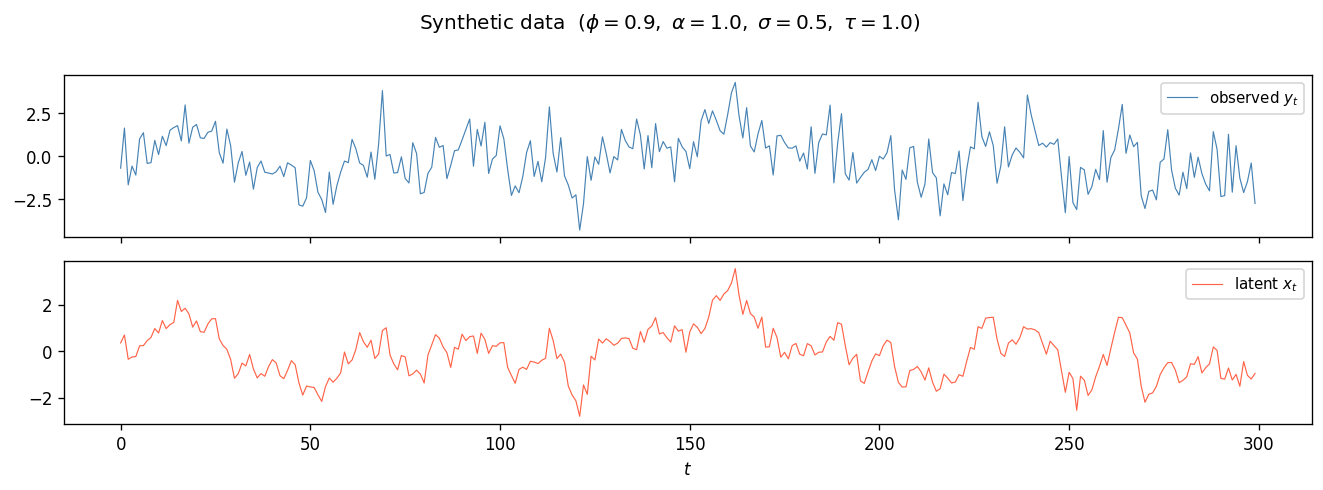

In [2]:
# ── true parameters and synthetic dataset ─────────────────────────────────────
TRUE_PARAMS = dict(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0)
T    = 300
SEED = 42

model = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=SEED)
states_raw, obs_raw, cond_loglik = model.generate_data(T)
states = states_raw.ravel()   # (T,)
obs    = obs_raw.ravel()      # (T,)

# Note: cond_loglik = Σ log p(y_t|x_t, θ*) — the conditional likelihood given
# the realized latent path, NOT the marginal log p(y|θ*) from the Kalman filter.
print(f"T={T}  conditional log p(y|x*,θ*)={float(cond_loglik):.2f}")
print(f"True params: {TRUE_PARAMS}")

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
axes[0].plot(obs,    lw=0.7, color='steelblue', label='observed $y_t$')
axes[1].plot(states, lw=0.7, color='tomato',    label='latent $x_t$')
for ax in axes:
    ax.legend(loc='upper right', fontsize=9)
axes[1].set_xlabel('$t$')
fig.suptitle(
    r'Synthetic data  ($\phi=0.9,\ \alpha=1.0,\ \sigma=0.5,\ \tau=1.0$)',
    y=1.01,
)
plt.tight_layout()
plt.show()

In [3]:
# ── MLE via MLEEstimator ──────────────────────────────────────────────────────
# MLEEstimator maximizes model.log_likelihood(data) using scipy.optimize.minimize
# (L-BFGS-B by default).  Optimization happens in the *unconstrained* parameter
# space (atanh φ, α, log σ, log τ) so no box constraints are needed; results
# are mapped back to the constrained space in MLEResult.constrained_params.
#
# n_restarts=3: the best optimum over 3 random restarts is returned, which helps
# avoid local optima that can appear with highly persistent AR processes.

mle = MLEEstimator(model, obs, n_restarts=3, restart_std=0.3, seed=0)
result = mle.fit()
mle.compute_std_errors()   # numerical Hessian + delta method → fills result.std_errors

print(result.summary())

MLEEstimator.fit  0.120s
MLEResult  loglik=-495.5197  converged  n_evals=65
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.852314      0.053785
  alpha                 0.942855             —
  sigma                 0.619063             —
  tau                   0.987916      0.073832


Param         True         MLE          SE   |bias|/SE
────────────────────────────────────────────────────
phi         0.9000      0.8523      0.0538        0.89
alpha       1.0000      0.9429           —           —
sigma       0.5000      0.6191           —           —
tau         1.0000      0.9879      0.0738        0.16


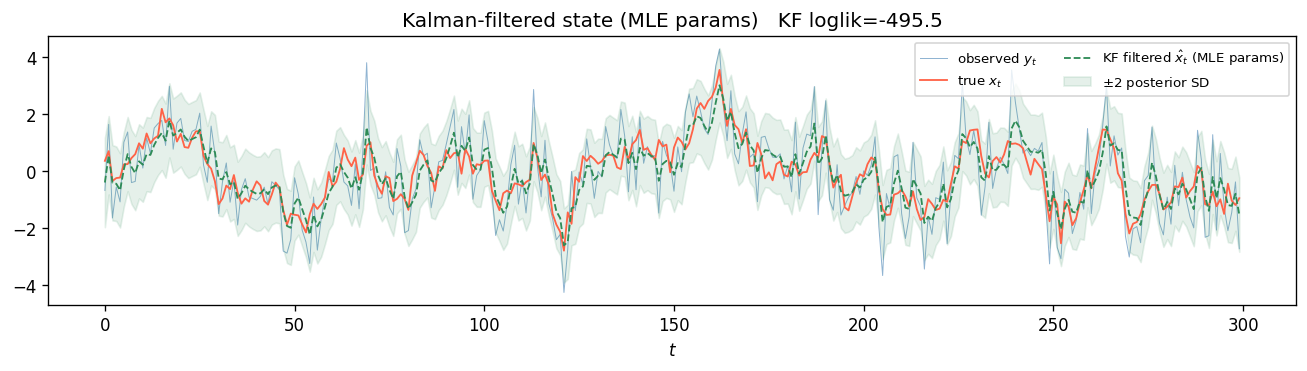

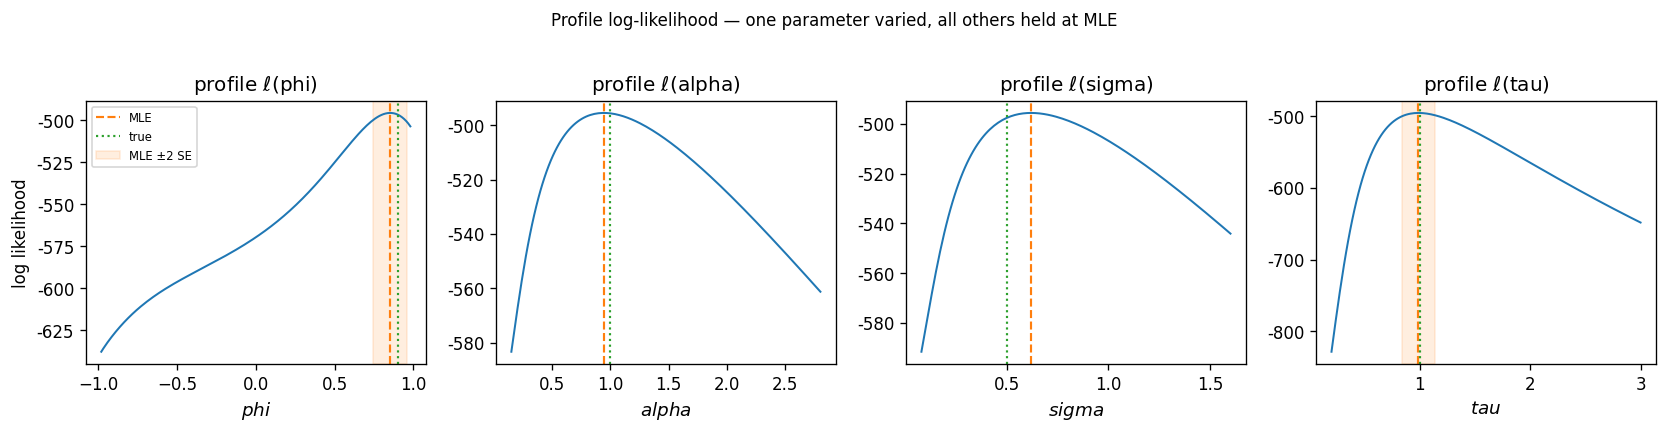

In [4]:
# ── comparison table and plots ────────────────────────────────────────────────
names   = result.param_names                  # ['phi', 'alpha', 'sigma', 'tau']
mle_est = list(result.constrained_params)
ses     = list(result.std_errors) if result.std_errors is not None else [None] * 4
trues   = [TRUE_PARAMS[p] for p in names]

print(f"{'Param':<8}  {'True':>8}  {'MLE':>10}  {'SE':>10}  {'|bias|/SE':>10}")
print("─" * 52)
for name, tv, mv, se in zip(names, trues, mle_est, ses):
    if se is not None and not np.isnan(se) and se > 0:
        print(f"{name:<8}  {tv:>8.4f}  {mv:>10.4f}  {se:>10.4f}  {abs(mv-tv)/se:>10.2f}")
    else:
        print(f"{name:<8}  {tv:>8.4f}  {mv:>10.4f}  {'—':>10}  {'—':>10}")

# ── Kalman filter with MLE params → filtered state ────────────────────────────
phi_m, alpha_m, sigma_m, tau_m = mle_est
lg_mle = LinearGaussianSSM(
    a=np.array([[phi_m]]),
    c=np.array([[alpha_m]]),
    q=np.array([[sigma_m**2]]),
    r=np.array([[tau_m**2]]),
)
kf_mle = KalmanFilter(lg_mle, obs)
filt_means, filt_covs, kf_loglik = kf_mle.run_filter()
filt_std = np.sqrt(filt_covs[:, 0, 0])

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(obs,    lw=0.6, color='steelblue', alpha=0.6, label='observed $y_t$', zorder=1)
ax.plot(states, lw=1.1, color='tomato',    label='true $x_t$',                zorder=2)
ax.plot(filt_means[:, 0], lw=1.1, color='seagreen', ls='--',
        label=r'KF filtered $\hat{x}_t$ (MLE params)', zorder=3)
ax.fill_between(range(T),
                filt_means[:, 0] - 2 * filt_std,
                filt_means[:, 0] + 2 * filt_std,
                color='seagreen', alpha=0.12, label=r'$\pm$2 posterior SD')
ax.set_xlabel('$t$')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_title(f'Kalman-filtered state (MLE params)   KF loglik={kf_loglik:.1f}')
plt.tight_layout()
plt.show()

# ── profile log-likelihoods (1-D slices through MLE) ─────────────────────────
grids = {
    'phi':   np.linspace(-0.98, 0.98, 150),
    'alpha': np.linspace(0.15, 2.80, 150),
    'sigma': np.linspace(0.08, 1.60, 150),
    'tau':   np.linspace(0.20, 3.00, 150),
}
mle_dict = dict(zip(names, mle_est))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, name in zip(axes, names):
    lls = []
    for v in grids[name]:
        kwargs = {**mle_dict, name: v}
        try:
            m_tmp = SimpleLinearGaussianSSM(**kwargs)
            lls.append(m_tmp.log_likelihood(obs))
        except (ValueError, FloatingPointError):
            lls.append(np.nan)
    lls = np.array(lls)

    ax.plot(grids[name], lls, lw=1.2, color='C0')
    ax.axvline(mle_dict[name],    color='C1', ls='--', lw=1.3, label='MLE')
    ax.axvline(TRUE_PARAMS[name], color='C2', ls=':',  lw=1.3, label='true')

    idx = names.index(name)
    se  = ses[idx]
    if se is not None and not np.isnan(se) and se > 0:
        ax.axvspan(mle_dict[name] - 2*se, mle_dict[name] + 2*se,
                   alpha=0.13, color='C1', label='MLE ±2 SE')

    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'profile $\\ell$({name})')
    if name == names[0]:
        ax.set_ylabel('log likelihood')
        ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

plt.suptitle('Profile log-likelihood — one parameter varied, all others held at MLE',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# Note: alpha and sigma show no ±2 SE band because the Hessian is near-singular
# along the α·σ identification ridge — explored in Section 4.

---
## 2.1 Metropolis-Hastings via exact log-likelihood

For `SimpleLinearGaussianSSM` the marginal log-likelihood $\log p(y_{1:T} \mid \theta)$ is
available in closed form via the Kalman filter recursion.  `MetropolisHastings` exploits this
to run *exact* random-walk MH — acceptance decisions use the true log-likelihood with no
particle noise.

The sampler targets the change-of-variables posterior in unconstrained space:

$$\pi(z) \propto p(y \mid \theta(z)) \cdot p_\text{prior}(\theta(z)) \cdot |\!\det J(z)|$$

where $z$ is the unconstrained parameter vector, $\theta(z) = \texttt{constrain\_params}(z)$,
and $J(z) = d\theta/dz$ is the Jacobian of the reparameterisation.  The Jacobian does **not**
cancel in the acceptance ratio because $J(z_\text{prop}) \neq J(z_\text{curr})$ for nonlinear
transforms (tanh, exp).  Both terms are computed automatically by `_log_prior_and_jac`.

We warm-start from the MLE optimum (Section 1) and use the same synthetic dataset, so that
posteriors can be directly compared to MLE point estimates and their asymptotic standard errors.
Section 2.2 replaces the exact log-likelihood with a particle filter estimate (PMMH) and shows
the effect of particle noise on mixing and posterior width.

In [5]:
# ── MH setup ──────────────────────────────────────────────────────────────────
N_ITER_MH = 3000
BURN_IN_MH = 500
step_mh   = np.array([0.06, 0.10, 0.06, 0.06])

model_mh  = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=13)
theta0_mh = result.unconstrained_params   # warm start from MLE

mh = MetropolisHastings(model_mh, obs, n_iter=N_ITER_MH,
                        step_sizes=step_mh, theta0=theta0_mh,
                        log_prior=log_prior, seed=1)
print(repr(mh))

MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0), n_iter=3000)


In [6]:
print("Running Metropolis-Hastings (exact Kalman log-likelihood, 3000 iterations) ...")
chain_mh, ll_mh, acc_mh = mh.run()

constrained_mh = model_mh.constrain_chain(chain_mh[BURN_IN_MH:])

mh.summary(burn=BURN_IN_MH)

print(f"\n{'Param':<8}  {'True':>8}  {'Post mean':>10}  {'Post std':>10}  {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(model_mh.params_dict.keys()):
    samp = constrained_mh[:, k]
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{samp.mean():>10.4f}  {samp.std():>10.4f}  {chain_ess(samp):>8.1f}")

Running Metropolis-Hastings (exact Kalman log-likelihood, 3000 iterations) ...
MetropolisHastings.run  1.167s
param              mean        std
----------------------------------
phi              0.8357     0.0500
alpha            1.4742     0.5589
sigma            0.4685     0.1958
tau              0.9791     0.0772

Acceptance rate: 0.517  (burn=500)

Param         True   Post mean    Post std       ESS
────────────────────────────────────────────────────
phi         0.9000      0.8357      0.0500      36.8
alpha       1.0000      1.4742      0.5589       9.0
sigma       0.5000      0.4685      0.1958       9.0
tau         1.0000      0.9791      0.0772      98.5


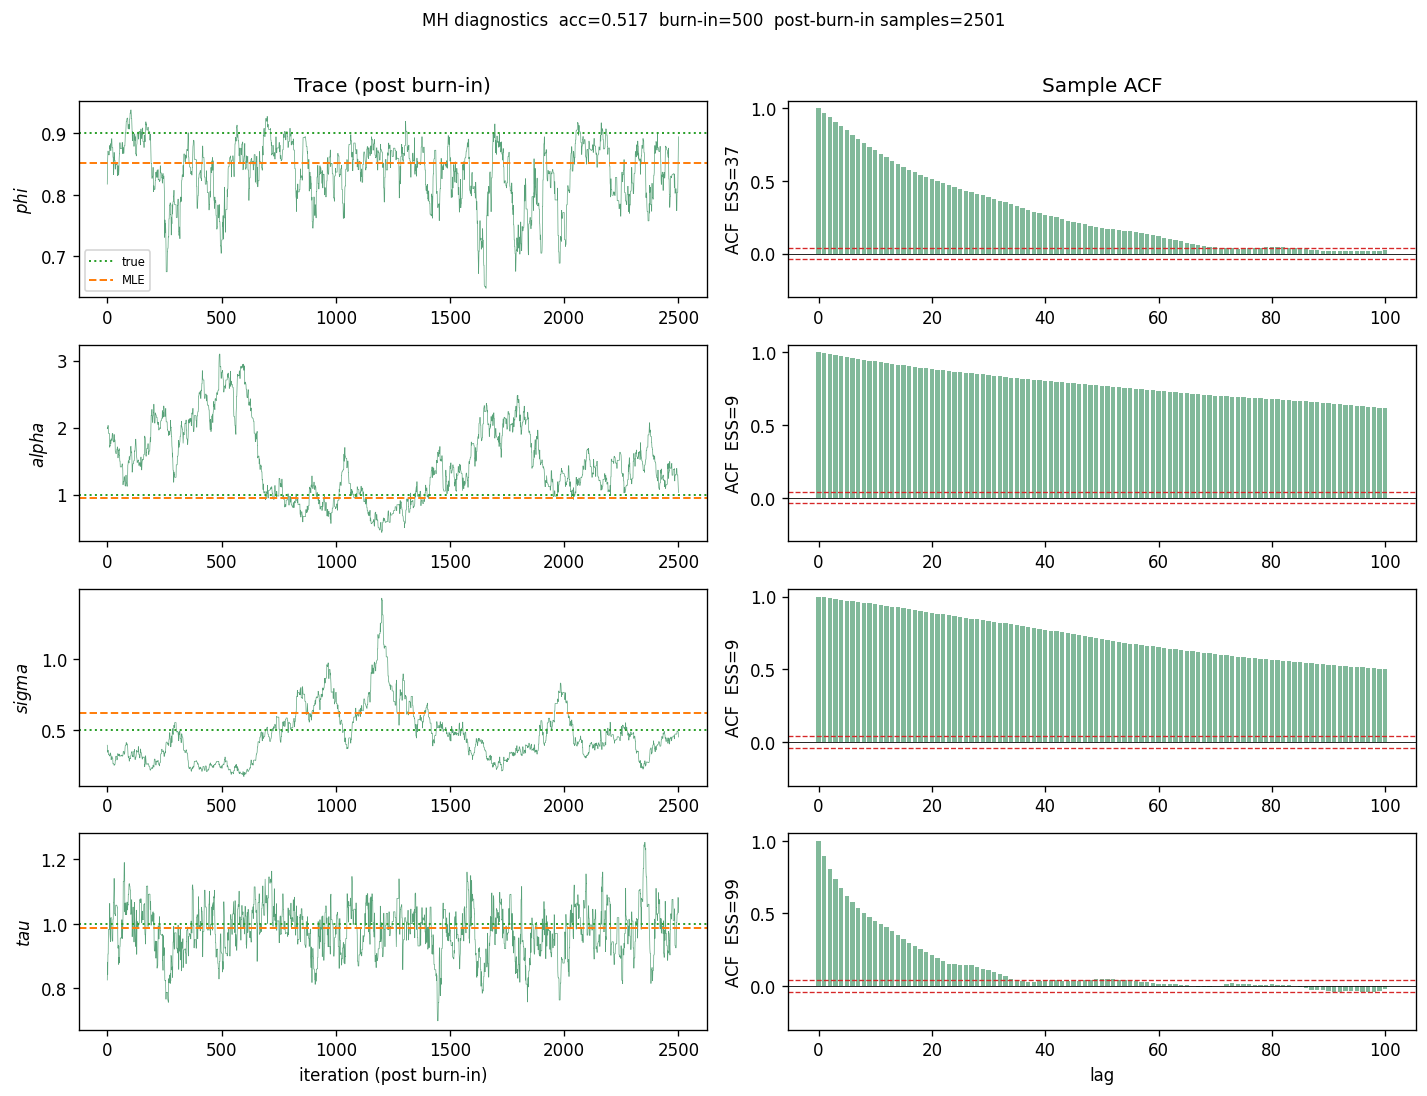

In [7]:
names_mh = list(model_mh.params_dict.keys())
fig, axes = plt.subplots(4, 2, figsize=(12, 9))

for k, name in enumerate(names_mh):
    samp = constrained_mh[:, k]
    tv   = TRUE_PARAMS[name]
    mv   = list(result.constrained_params)[k]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='seagreen', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2)
    ax_t.axhline(mv, color='C1', ls='--', lw=1.2)
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.plot([], [], color='C2', ls=':', lw=1.2, label='true')
        ax_t.plot([], [], color='C1', ls='--', lw=1.2, label='MLE')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s  = len(samp)
    max_lag = min(100, n_s - 1)
    xc  = samp - samp.mean()
    var = xc.var()
    acf = np.correlate(xc, xc, 'full')[n_s - 1:] / (n_s * var) if var > 1e-15 else np.zeros(n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1], width=0.8, color='seagreen', alpha=0.6)
    ax_a.axhline(0, color='k', lw=0.5)
    ci = 1.96 / np.sqrt(n_s)
    ax_a.axhline( ci, color='C3', ls='--', lw=0.8)
    ax_a.axhline(-ci, color='C3', ls='--', lw=0.8)
    ax_a.set_ylim(-0.3, 1.05)
    ax_a.set_ylabel(f'ACF  ESS={chain_ess(samp):.0f}')
    if k == 0:
        ax_a.set_title('Sample ACF')

axes[-1, 0].set_xlabel('iteration (post burn-in)')
axes[-1, 1].set_xlabel('lag')
plt.suptitle(
    f'MH diagnostics  acc={acc_mh.mean():.3f}  '
    f'burn-in={BURN_IN_MH}  post-burn-in samples={len(constrained_mh)}',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

Note that alpha and sigma have very low ESS due to weak identifiability issue.

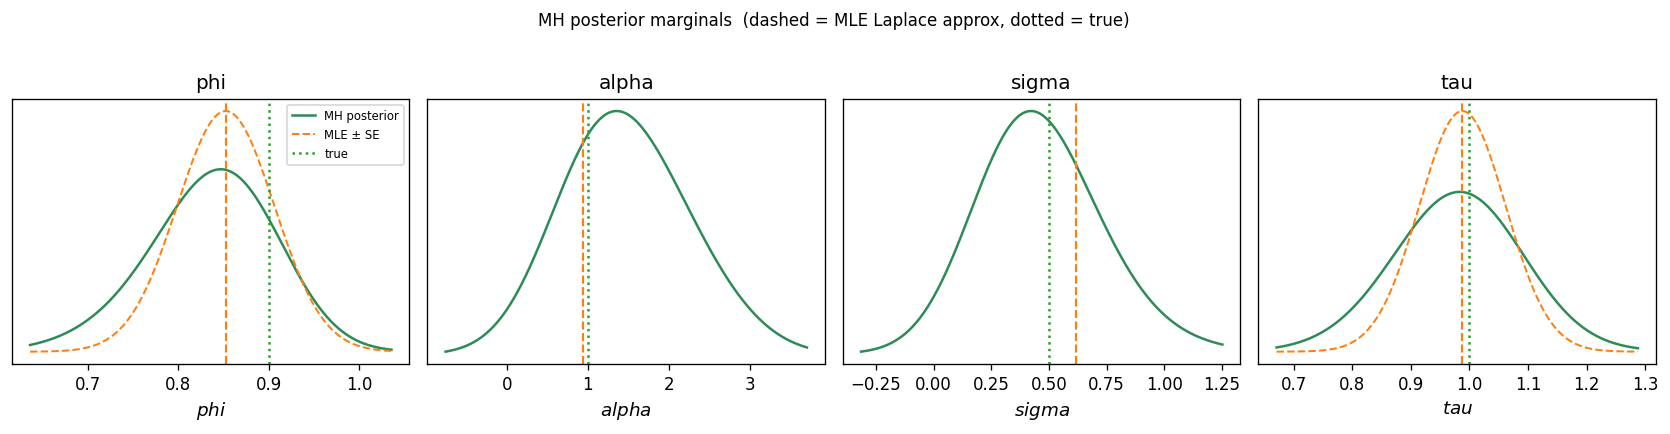

In [8]:
from scipy.stats import norm as _sp_norm

names_mh    = list(model_mh.params_dict.keys())
con_list_mh = list(result.constrained_params)
se_list_mh  = list(result.std_errors) if result.std_errors is not None else [None] * 4

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for k, (ax, name) in enumerate(zip(axes, names_mh)):
    samp = constrained_mh[:, k]
    tv   = TRUE_PARAMS[name]
    mv   = con_list_mh[k]
    se   = se_list_mh[k]

    kde = KDE(samp)
    lo  = samp.mean() - 4 * samp.std()
    hi  = samp.mean() + 4 * samp.std()
    xg  = np.linspace(lo, hi, 400)
    ax.plot(xg, kde.evaluate(xg), lw=1.5, color='seagreen', label='MH posterior')

    if se is not None and not np.isnan(se) and se > 0:
        ax.plot(xg, _sp_norm.pdf(xg, mv, se), lw=1.2, ls='--', color='C1',
                label='MLE ± SE')

    ax.axvline(tv, color='C2', ls=':', lw=1.5, label='true')
    ax.axvline(mv, color='C1', ls='--', lw=1.3)
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(name)
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle('MH posterior marginals  (dashed = MLE Laplace approx, dotted = true)',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

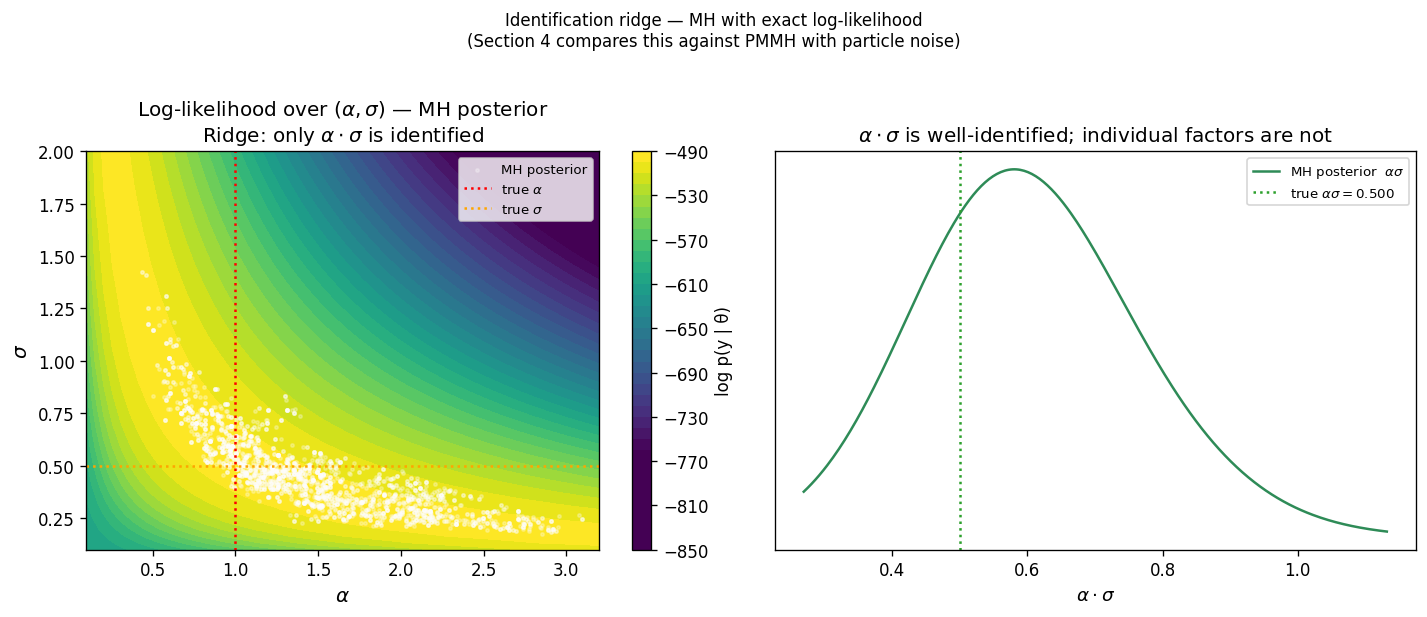

In [9]:
# ── α·σ identification ridge in the MH posterior ─────────────────────────────
# Compute the 2-D Kalman log-likelihood over (alpha, sigma) with phi, tau fixed
# at their true values, then overlay the MH samples to show the chain traces the
# ridge exactly.  Section 4 repeats this with PMMH to show the effect of particle
# noise on the same structural non-identifiability.
phi_fix      = TRUE_PARAMS["phi"]
tau_fix      = TRUE_PARAMS["tau"]
n_grid_ridge = 60

alpha_g = np.linspace(0.1, 3.2, n_grid_ridge)
sigma_g = np.linspace(0.1, 2, n_grid_ridge)
AA_mh, SS_mh = np.meshgrid(alpha_g, sigma_g)
LL_mh = np.full_like(AA_mh, np.nan)

for i in range(n_grid_ridge):
    for j in range(n_grid_ridge):
        try:
            m_tmp = SimpleLinearGaussianSSM(phi_fix, AA_mh[i, j], SS_mh[i, j], tau_fix)
            LL_mh[i, j] = m_tmp.log_likelihood(obs)
        except (ValueError, FloatingPointError):
            pass

alpha_samp = constrained_mh[:, 1]   # alpha column
sigma_samp = constrained_mh[:, 2]   # sigma column
prod_true  = TRUE_PARAMS["alpha"] * TRUE_PARAMS["sigma"]
prod_mh    = alpha_samp * sigma_samp

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── left: contour + MH scatter ───────────────────────────────────────────────
ax = axes[0]
vmin_r = np.nanpercentile(LL_mh, 5)
cf = ax.contourf(AA_mh, SS_mh, LL_mh, levels=40, cmap="viridis",
                 vmin=vmin_r, vmax=np.nanmax(LL_mh))
plt.colorbar(cf, ax=ax, label="log p(y | θ)")
ax.scatter(alpha_samp, sigma_samp, c="white", s=4, alpha=0.25,
           label="MH posterior", rasterized=True)
ax.axvline(TRUE_PARAMS["alpha"], color="red",    ls=":", lw=1.5, label=r"true $\alpha$")
ax.axhline(TRUE_PARAMS["sigma"], color="orange", ls=":", lw=1.5, label=r"true $\sigma$")
ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel(r"$\sigma$", fontsize=12)
ax.set_title(
    r"Log-likelihood over $(\alpha, \sigma)$ — MH posterior" "\n"
    r"Ridge: only $\alpha \cdot \sigma$ is identified"
)
ax.legend(fontsize=8)

# ── right: 1-D KDE of α·σ ────────────────────────────────────────────────────
ax2 = axes[1]
kde_prod = KDE(prod_mh)
xg = np.linspace(max(0.0, prod_mh.min() - 0.05), prod_mh.max() + 0.05, 300)
ax2.plot(xg, kde_prod.evaluate(xg), lw=1.5, color="seagreen",
         label=r"MH posterior  $\alpha\sigma$")
ax2.axvline(prod_true, color="C2", ls=":", lw=1.5,
            label=fr"true $\alpha\sigma = {prod_true:.3f}$")
ax2.set_xlabel(r"$\alpha \cdot \sigma$", fontsize=11)
ax2.set_title(r"$\alpha \cdot \sigma$ is well-identified; individual factors are not")
ax2.legend(fontsize=8)
ax2.set_yticks([])

plt.suptitle(
    r"Identification ridge — MH with exact log-likelihood" "\n"
    r"(Section 4 compares this against PMMH with particle noise)",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

---

# 2.1.2 Metropolis Hastings with fixed alpha
Due to the non-identifiability of the alpha·sigma ridge, here we fix alpha = 1 and estimate the other three parameters using MH.

In [10]:
# ── 2.1.2 — FixedAlphaSSM: alpha fixed at 1.0, estimate (phi, sigma, tau) ────
# Fixing alpha breaks the alpha·sigma ridge and makes the posterior identifiable.

class FixedAlphaSSM(SimpleLinearGaussianSSM):
    """SimpleLinearGaussianSSM with alpha fixed at 1; estimates (phi, sigma, tau)."""
    ALPHA_FIXED = 1.0

    def __init__(self, phi, sigma, tau, seed=None):
        super().__init__(phi=phi, alpha=self.ALPHA_FIXED, sigma=sigma, tau=tau, seed=seed)
        self.params_dict = {'phi': phi, 'sigma': sigma, 'tau': tau}

    def update_params(self, constrained_params):
        phi, sigma, tau = constrained_params
        self.phi   = phi
        self.alpha = self.ALPHA_FIXED
        self.sigma = sigma
        self.tau   = tau
        self.params_dict = {'phi': phi, 'sigma': sigma, 'tau': tau}
        self.check_params_validity()

    def unconstrain_params(self, constrained_params):
        phi, sigma, tau = constrained_params
        return np.array([np.arctanh(phi), np.log(sigma), np.log(tau)])

    def constrain_params(self, unconstrained_params):
        u_phi, u_sigma, u_tau = unconstrained_params
        return [float(np.tanh(u_phi)), float(np.exp(u_sigma)), float(np.exp(u_tau))]

    def jacobian_constrain_params(self, unconstrained_params):
        u_phi, u_sigma, u_tau = unconstrained_params
        return np.diag([
            1.0 - np.tanh(u_phi) ** 2,
            np.exp(u_sigma),
            np.exp(u_tau),
        ])


def log_prior_fixed_alpha(theta_con):
    """Independent priors on (phi, sigma, tau) with alpha fixed."""
    phi, sigma, tau = theta_con
    if phi <= -1 or phi >= 1:
        return -np.inf
    if sigma <= 0 or tau <= 0:
        return -np.inf
    return sum([
        np.log(2) - np.log(1 + phi ** 2),   # Cauchy(0,1) on (-1,1) for phi
        -np.log(sigma),                       # HalfCauchy(0,1) ∝ 1/sigma
        -np.log(tau),                         # HalfCauchy(0,1) ∝ 1/tau
    ])


N_ITER_FA  = 3000
BURN_IN_FA = 500

model_fa  = FixedAlphaSSM(phi=TRUE_PARAMS['phi'], sigma=TRUE_PARAMS['sigma'],
                           tau=TRUE_PARAMS['tau'], seed=5)
theta0_fa = model_fa.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma'], TRUE_PARAMS['tau']]
)

mh_fa = MetropolisHastings(
    model_fa, obs,
    n_iter=N_ITER_FA,
    step_sizes=np.array([0.06, 0.06, 0.06]),
    theta0=theta0_fa,
    log_prior=log_prior_fixed_alpha,
    seed=3,
)
print(mh_fa)


MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0), n_iter=3000)


In [11]:
print("Running MH with fixed alpha=1.0 (3000 iterations) ...")
chain_fa, ll_fa, acc_fa = mh_fa.run()

constrained_fa = model_fa.constrain_chain(chain_fa[BURN_IN_FA:])

mh_fa.summary(burn=BURN_IN_FA)

names_fa   = list(model_fa.params_dict.keys())
true_fa    = [TRUE_PARAMS[p] for p in names_fa]

print(f"\n{'Param':<8}  {'True':>8}  {'Post mean':>10}  {'Post std':>10}  {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    print(f"{name:<8}  {true_fa[k]:>8.4f}  "
          f"{samp.mean():>10.4f}  {samp.std():>10.4f}  {chain_ess(samp):>8.1f}")


Running MH with fixed alpha=1.0 (3000 iterations) ...
MetropolisHastings.run  1.187s
param              mean        std
----------------------------------
phi              0.8349     0.0614
sigma            0.6248     0.1206
tau              0.9648     0.0804

Acceptance rate: 0.582  (burn=500)

Param         True   Post mean    Post std       ESS
────────────────────────────────────────────────────
phi         0.9000      0.8349      0.0614      34.0
sigma       0.5000      0.6248      0.1206      27.8
tau         1.0000      0.9648      0.0804      42.6


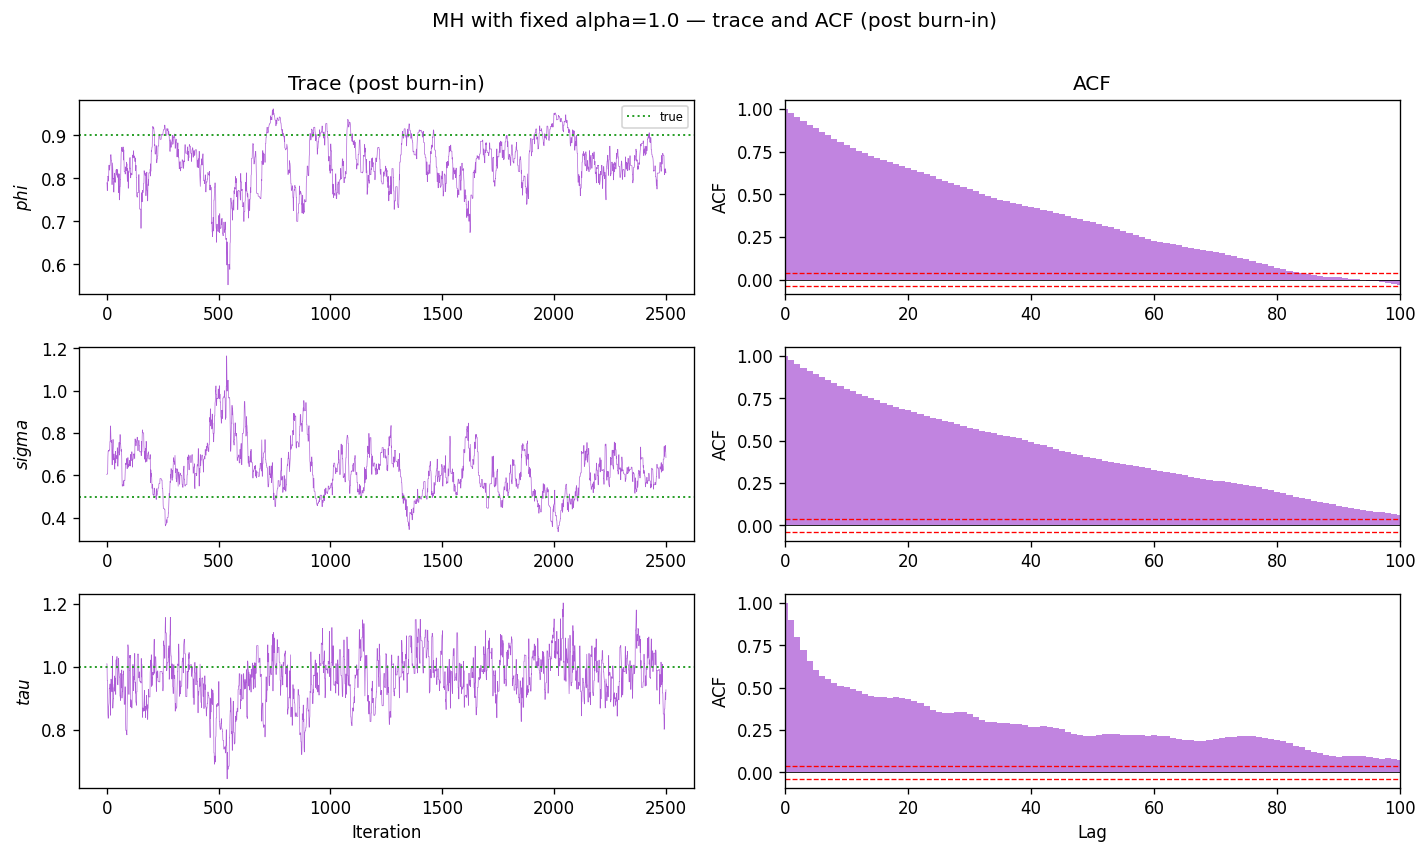

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='darkorchid', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2, label='true')
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s     = len(samp)
    max_lag = min(100, n_s - 1)
    xc      = samp - samp.mean()
    var     = xc.var()
    acf     = np.correlate(xc, xc, mode='full')[n_s - 1:] / (var * n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1],
             width=1.0, color='darkorchid', alpha=0.6)
    ax_a.axhline(0,  color='black', lw=0.5)
    ax_a.axhline( 1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.axhline(-1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.set_xlim(0, max_lag)
    ax_a.set_ylabel('ACF')
    if k == 0:
        ax_a.set_title('ACF')

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Lag')
plt.suptitle('MH with fixed alpha=1.0 — trace and ACF (post burn-in)', y=1.01)
plt.tight_layout()
plt.show()


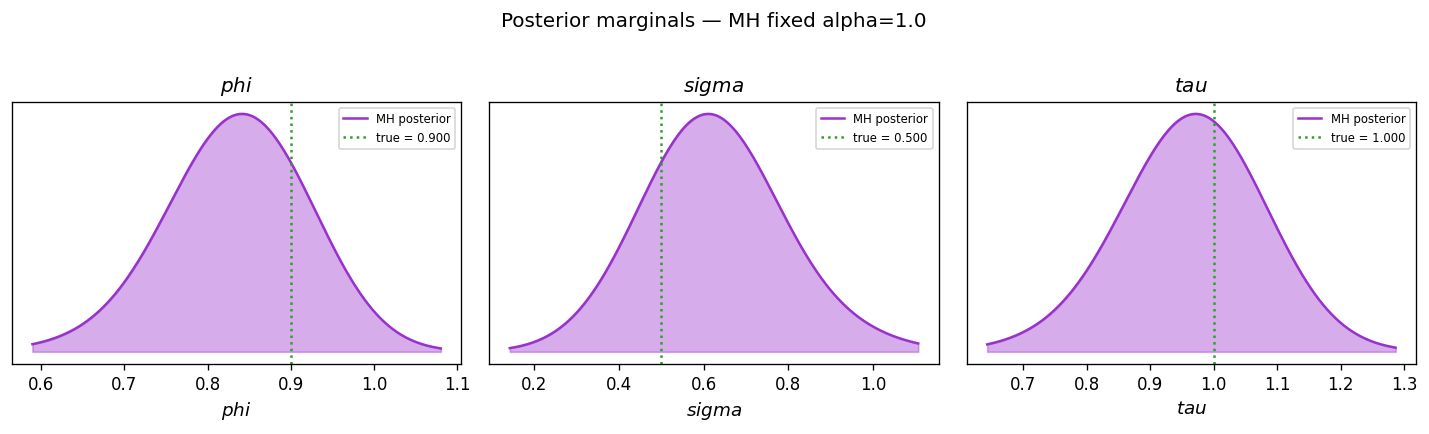

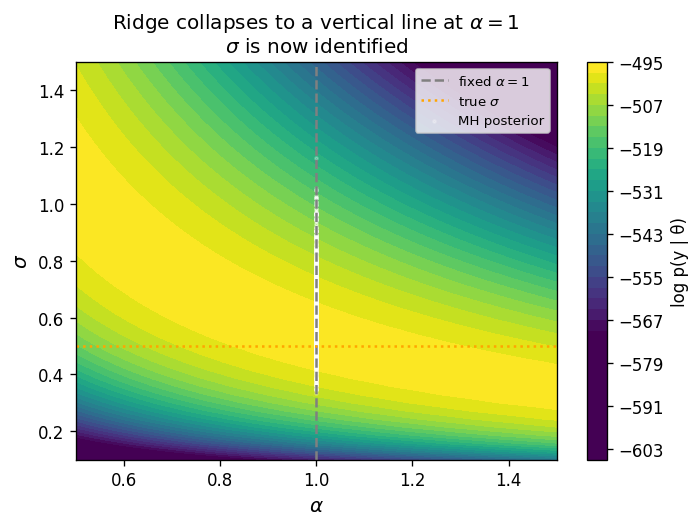

In [36]:
# ── Posterior KDEs and the collapsed ridge ────────────────────────────────────
from scipy.stats import norm as _sp_norm

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for k, (ax, name) in enumerate(zip(axes, names_fa)):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    kde = KDE(samp)
    lo  = samp.mean() - 4 * samp.std()
    hi  = samp.mean() + 4 * samp.std()
    xg  = np.linspace(lo, hi, 300)
    ax.fill_between(xg, kde.evaluate(xg), alpha=0.4, color='darkorchid')
    ax.plot(xg, kde.evaluate(xg), lw=1.5, color='darkorchid', label='MH posterior')
    ax.axvline(tv, color='C2', ls=':', lw=1.5, label=f'true = {tv:.3f}')
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'${name}$')
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.suptitle('Posterior marginals — MH fixed alpha=1.0', y=1.02)
plt.tight_layout()
plt.show()

# ── Residual alpha·sigma scatter to confirm ridge is gone ─────────────────────
phi_fix_fa  = TRUE_PARAMS['phi']
tau_fix_fa  = TRUE_PARAMS['tau']
n_grid_fa   = 50

alpha_gfa = np.linspace(0.5, 1.5, n_grid_fa)   # narrow range around fixed alpha=1
sigma_gfa = np.linspace(0.1, 1.5, n_grid_fa)
AA_fa, SS_fa = np.meshgrid(alpha_gfa, sigma_gfa)
LL_fa = np.full_like(AA_fa, np.nan)

for i in range(n_grid_fa):
    for j in range(n_grid_fa):
        try:
            m_tmp = SimpleLinearGaussianSSM(phi_fix_fa, AA_fa[i, j], SS_fa[i, j], tau_fix_fa)
            LL_fa[i, j] = m_tmp.log_likelihood(obs)
        except (ValueError, FloatingPointError):
            pass

sigma_samp_fa = constrained_fa[:, 1]  # sigma column (index 1; phi=0, sigma=1, tau=2)

fig, ax = plt.subplots(figsize=(6, 4.5))
vmin_fa = np.nanpercentile(LL_fa, 5)
cf = ax.contourf(AA_fa, SS_fa, LL_fa, levels=40, cmap='viridis',
                 vmin=vmin_fa, vmax=np.nanmax(LL_fa))
plt.colorbar(cf, ax=ax, label='log p(y | θ)')
ax.axvline(1.0,               color='grey', ls='--', lw=1.5, label=r'fixed $\alpha=1$')
ax.axhline(TRUE_PARAMS['sigma'], color='orange', ls=':',  lw=1.5, label=r'true $\sigma$')
ax.scatter([1.0] * len(sigma_samp_fa), sigma_samp_fa,
           c='white', s=3, alpha=0.25, rasterized=True, label='MH posterior')
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel(r'$\sigma$', fontsize=12)
ax.set_title(
    r'Ridge collapses to a vertical line at $\alpha=1$' '\n'
    r'$\sigma$ is now identified'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
## 2.2 PMMH parameter estimation

Particle Marginal Metropolis-Hastings replaces the intractable marginal likelihood
$p(y_{1:T} \mid \theta)$ with the particle filter's unbiased estimator $\hat{p}_N(y_{1:T} \mid \theta)$ (Note that although the likelihood estimator is unbiased, the log-likelihood is not due to Jensen's inequality).
The resulting chain targets the exact posterior $p(\theta \mid y_{1:T})$ for any fixed $N$.

Setup:
- **Prior**: independent priors on each parameter (specified via `log_prior` in `PMMH`)
- **Proposal**: Gaussian random walk in the unconstrained space
- **Likelihood**: PF log-likelihood from `ParticleFilter.run_filter()`
- Parameters are constrained/unconstrained via `model.constrain_params` / `model.unconstrain_params`

We use the same synthetic dataset from Section 1 to allow direct comparison between MLE and PMMH estimates.

In [14]:
# ── PMMH on the Section 1 dataset ─────────────────────────────────────────────
# Fresh model instance; warm-start from the MLE optimum (result from Section 1).
N_ITER_2   = 3000
N_PART_2   = 1000
BURN_IN_2  = 500
step_2     = np.array([0.06, 0.10, 0.06, 0.06])   # unconstrained-space step sizes

model_2  = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=7)
theta0_2 = result.unconstrained_params             # warm start from MLE

pf_2    = ParticleFilter(model_2, N_PART_2, obs, SystematicResampling(seed=3))
pmmh_2  = PMMH(model_2, pf_2, n_iter=N_ITER_2,
               step_sizes=step_2, theta0=theta0_2, log_prior=log_prior, seed=5)
print(repr(pmmh_2))

PMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0), n_iter=3000, N_particles=1000)


In [15]:
print("Running PMMH (N=1000 particles, 3000 iterations) ...")
chain_2, ll_2, acc_2 = pmmh_2.run()
print(f"Acceptance rate: {acc_2.mean():.3f}")

constrained_2 = model_2.constrain_chain(chain_2[BURN_IN_2:])

print(f"\n{'Param':<8}  {'True':>8}  {'Post mean':>10}  {'Post std':>10}  {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(model_2.params_dict.keys()):
    samp = constrained_2[:, k]
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{samp.mean():>10.4f}  {samp.std():>10.4f}  {chain_ess(samp):>8.1f}")

Running PMMH (N=1000 particles, 3000 iterations) ...
[501/3000]  theta = [ 0.11257041  0.25222879 -0.04713572 -0.14332559],  loglik = -505.97,  accept rate = 0.278
[1001/3000]  theta = [ 0.21061124  0.49792432 -0.06835752 -0.39592513],  loglik = -502.87,  accept rate = 0.210
[1501/3000]  theta = [ 0.30981045  0.65741551 -0.02331067 -0.55420478],  loglik = -504.22,  accept rate = 0.216
[2001/3000]  theta = [ 0.42209282  0.74264526  0.1174649  -0.68528447],  loglik = -502.75,  accept rate = 0.192
[2501/3000]  theta = [ 0.51976912  0.81348981  0.29263485 -0.83294632],  loglik = -502.05,  accept rate = 0.178
PMMH.run  5661.402s
Acceptance rate: 0.166

Param         True   Post mean    Post std       ESS
────────────────────────────────────────────────────
phi         0.9000      0.5447      0.0534      60.2
alpha       1.0000      0.7806      0.4323       5.7
sigma       0.5000      1.9492      0.7879       5.3
tau         1.0000      0.3899      0.0983       6.9


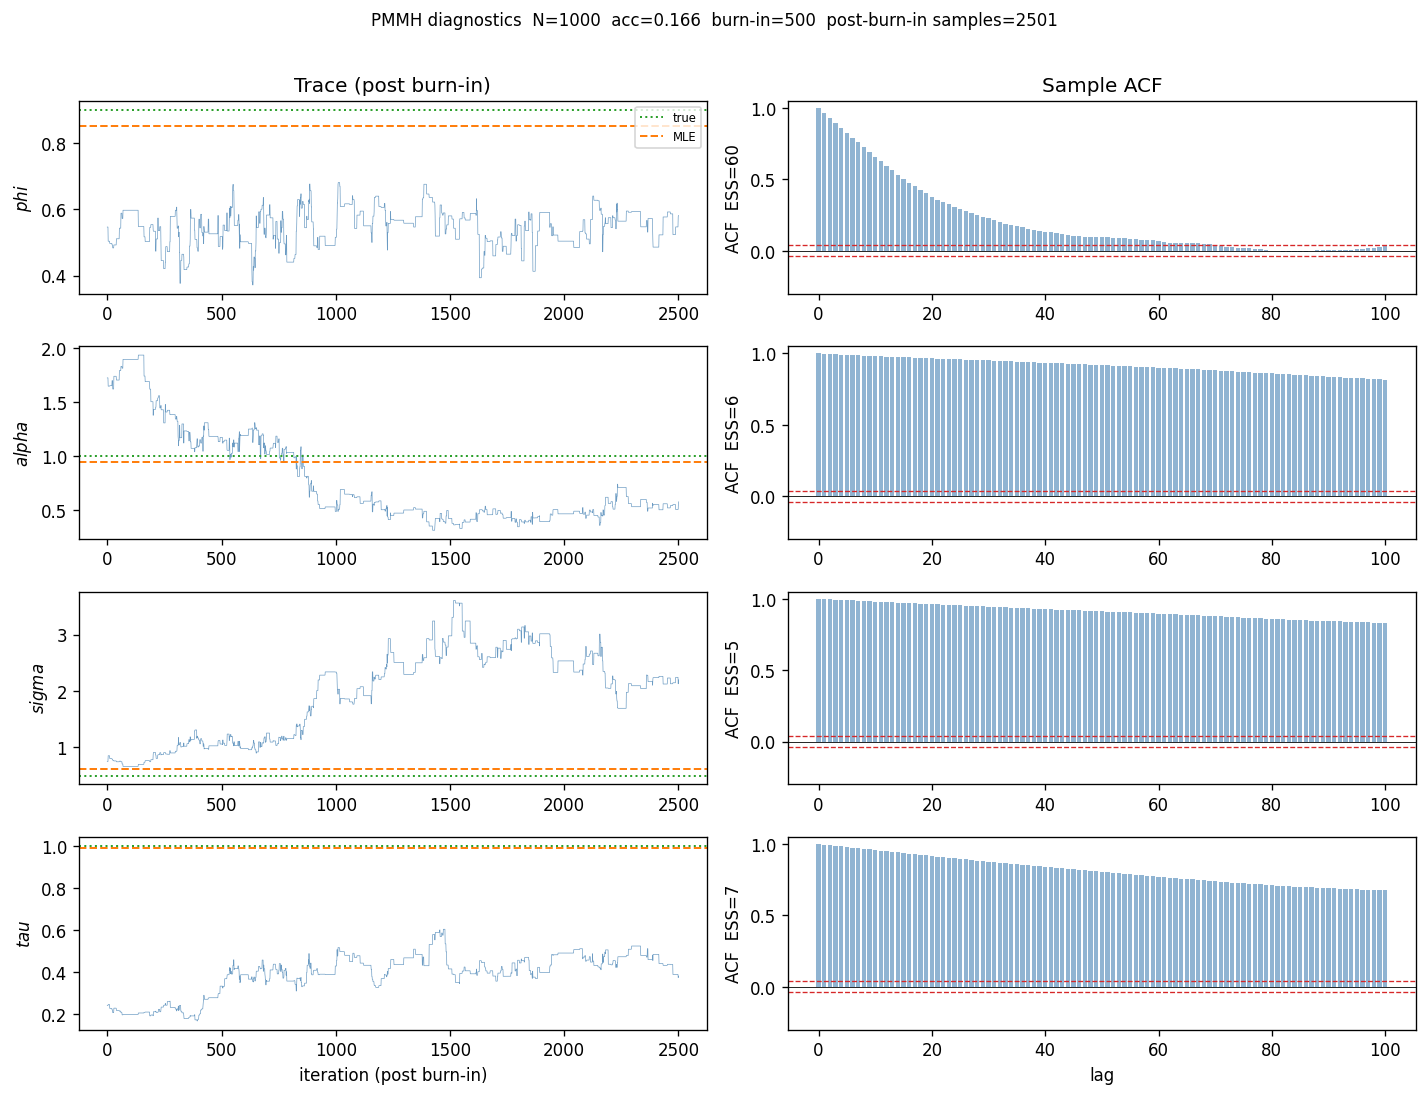

In [16]:
names_2 = list(model_2.params_dict.keys())
fig, axes = plt.subplots(4, 2, figsize=(12, 9))

for k, name in enumerate(names_2):
    samp = constrained_2[:, k]
    tv   = TRUE_PARAMS[name]
    mv   = list(result.constrained_params)[k]

    # ── trace ──────────────────────────────────────────────────────────────────
    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='steelblue', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2)
    ax_t.axhline(mv, color='C1', ls='--', lw=1.2)
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.plot([], [], color='C2', ls=':', lw=1.2, label='true')
        ax_t.plot([], [], color='C1', ls='--', lw=1.2, label='MLE')
        ax_t.legend(fontsize=7)

    # ── ACF ────────────────────────────────────────────────────────────────────
    ax_a = axes[k, 1]
    n_s  = len(samp)
    max_lag = min(100, n_s - 1)
    xc  = samp - samp.mean()
    var = xc.var()
    acf = np.correlate(xc, xc, 'full')[n_s - 1:] / (n_s * var) if var > 1e-15 else np.zeros(n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1], width=0.8, color='steelblue', alpha=0.6)
    ax_a.axhline(0, color='k', lw=0.5)
    ci = 1.96 / np.sqrt(n_s)
    ax_a.axhline( ci, color='C3', ls='--', lw=0.8)
    ax_a.axhline(-ci, color='C3', ls='--', lw=0.8)
    ax_a.set_ylim(-0.3, 1.05)
    ax_a.set_ylabel(f'ACF  ESS={chain_ess(samp):.0f}')
    if k == 0:
        ax_a.set_title('Sample ACF')

axes[-1, 0].set_xlabel('iteration (post burn-in)')
axes[-1, 1].set_xlabel('lag')
plt.suptitle(
    f'PMMH diagnostics  N={N_PART_2}  acc={acc_2.mean():.3f}  '
    f'burn-in={BURN_IN_2}  post-burn-in samples={len(constrained_2)}',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

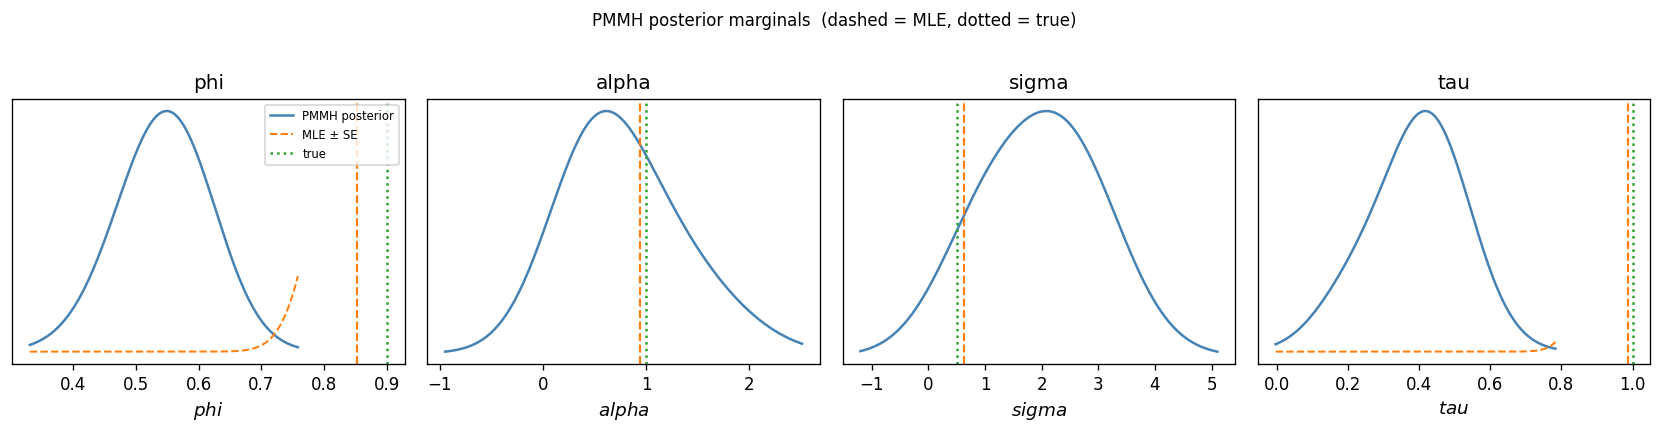

In [17]:
from scipy.stats import norm as _sp_norm

names_2    = list(model_2.params_dict.keys())
con_list_2 = list(result.constrained_params)
se_list_2  = list(result.std_errors) if result.std_errors is not None else [None] * 4

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for k, (ax, name) in enumerate(zip(axes, names_2)):
    samp = constrained_2[:, k]
    tv   = TRUE_PARAMS[name]
    mv   = con_list_2[k]
    se   = se_list_2[k]

    kde = KDE(samp)
    lo  = samp.mean() - 4 * samp.std()
    hi  = samp.mean() + 4 * samp.std()
    xg  = np.linspace(lo, hi, 400)
    ax.plot(xg, kde.evaluate(xg), lw=1.5, color='steelblue', label='PMMH posterior')

    if se is not None and not np.isnan(se) and se > 0:
        ax.plot(xg, _sp_norm.pdf(xg, mv, se), lw=1.2, ls='--', color='C1',
                label='MLE ± SE')

    ax.axvline(tv, color='C2', ls=':', lw=1.5, label='true')
    ax.axvline(mv, color='C1', ls='--', lw=1.3)
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(name)
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle('PMMH posterior marginals  (dashed = MLE, dotted = true)', y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. Block PMMH — updating parameters in independent groups

Standard PMMH proposes a joint update to all $d$ parameters simultaneously.
With $d=4$ and posterior correlation between $\alpha$ and $\sigma$ (the identification ridge),
a large joint step is often rejected, slowing mixing.

**Block PMMH** (`BlockPMMH`) partitions $\theta$ into groups and cycles through them each
iteration, accepting or rejecting each block independently:
- **Dynamics block** $(\phi, \sigma)$ — indices 0 and 2 in the unconstrained vector
- **Observation block** $(\alpha, \tau)$ — indices 1 and 3

Per-block proposals allow each block's effective step size to remain well-tuned even as
the other block moves.  We run both samplers on the **same dataset as Section 1** and compare:
- Overall acceptance rates
- Trace plots and posterior ESS
- Posterior marginals overlaid against the KF MLE

In [18]:
# ── setup: naive PMMH and Block PMMH on the same dataset ─────────────────────
# Uses dataset, model, and MLE result from Section 1.
# Block structure: dynamics (phi=0, sigma=2) and observation (alpha=1, tau=3)
# in the unconstrained vector order [phi, alpha, sigma, tau].
BLOCKS      = [[0, 2], [1, 3]]   # dynamics block, observation block
N_ITER_CMP  = 2000
N_PART_CMP  = 500
BURN_IN_CMP = 500

theta0 = model.unconstrain_params(result.constrained_params)
step   = np.array([0.10, 0.15, 0.10, 0.10])   # per-dim step sizes (unconstrained)

pf_n   = ParticleFilter(model, N_PART_CMP, obs, SystematicResampling(seed=1))
pmmh_n = PMMH(model, pf_n, n_iter=N_ITER_CMP,
              step_sizes=step, theta0=theta0, log_prior=log_prior, seed=10)

pf_b   = ParticleFilter(model, N_PART_CMP, obs, SystematicResampling(seed=2))
pmmh_b = BlockPMMH(model, pf_b, n_iter=N_ITER_CMP,
                   step_sizes=step, theta0=theta0, log_prior=log_prior,
                   blocks=BLOCKS, seed=20)

print(repr(pmmh_n))
print(repr(pmmh_b))

PMMH(model=SimpleLinearGaussianSSM(phi=0.8523144028728165, alpha=0.9428554774711047, sigma=0.6190626316371978, tau=0.9877185994324796), n_iter=2000, N_particles=500)
BlockPMMH(model=SimpleLinearGaussianSSM(phi=0.8523144028728165, alpha=0.9428554774711047, sigma=0.6190626316371978, tau=0.9877185994324796), n_iter=2000, N_particles=500, n_blocks=2)


In [19]:
# ── run both chains ───────────────────────────────────────────────────────────
print("Running naive PMMH ...")
chain_n, ll_n, acc_n = pmmh_n.run()
print(f"  acceptance rate: {acc_n.mean():.3f}")

print("Running Block PMMH ...")
chain_b, ll_b, acc_b = pmmh_b.run()
print(f"  acceptance rate: {acc_b.mean():.3f}")

constrained_n = model.constrain_chain(chain_n[BURN_IN_CMP:])
constrained_b = model.constrain_chain(chain_b[BURN_IN_CMP:])

print(f"\n{'':8}  {'True':>8}  {'Naive mean':>12}  {'Block mean':>12}")
print("─" * 46)
for k, name in enumerate(model.params_dict.keys()):
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{constrained_n[:, k].mean():>12.4f}  "
          f"{constrained_b[:, k].mean():>12.4f}")

Running naive PMMH ...
[501/2000]  theta = [ 0.29374066  0.28089623 -0.16154737 -0.03836994],  loglik = -508.86,  accept rate = 0.090
[1001/2000]  theta = [ 0.4435278   0.60972438 -0.1919922  -0.21704557],  loglik = -501.94,  accept rate = 0.111
[1501/2000]  theta = [ 0.59721274  0.97780954 -0.24225319 -0.4584647 ],  loglik = -499.65,  accept rate = 0.099
PMMH.run  1862.342s
  acceptance rate: 0.080
Running Block PMMH ...
BlockPMMH.run  3689.048s
  acceptance rate: 0.205

              True    Naive mean    Block mean
──────────────────────────────────────────────
phi         0.9000        0.5356        0.6379
alpha       1.0000        1.3940        1.5140
sigma       0.5000        0.8637        0.6663
tau         1.0000        0.4325        0.4967


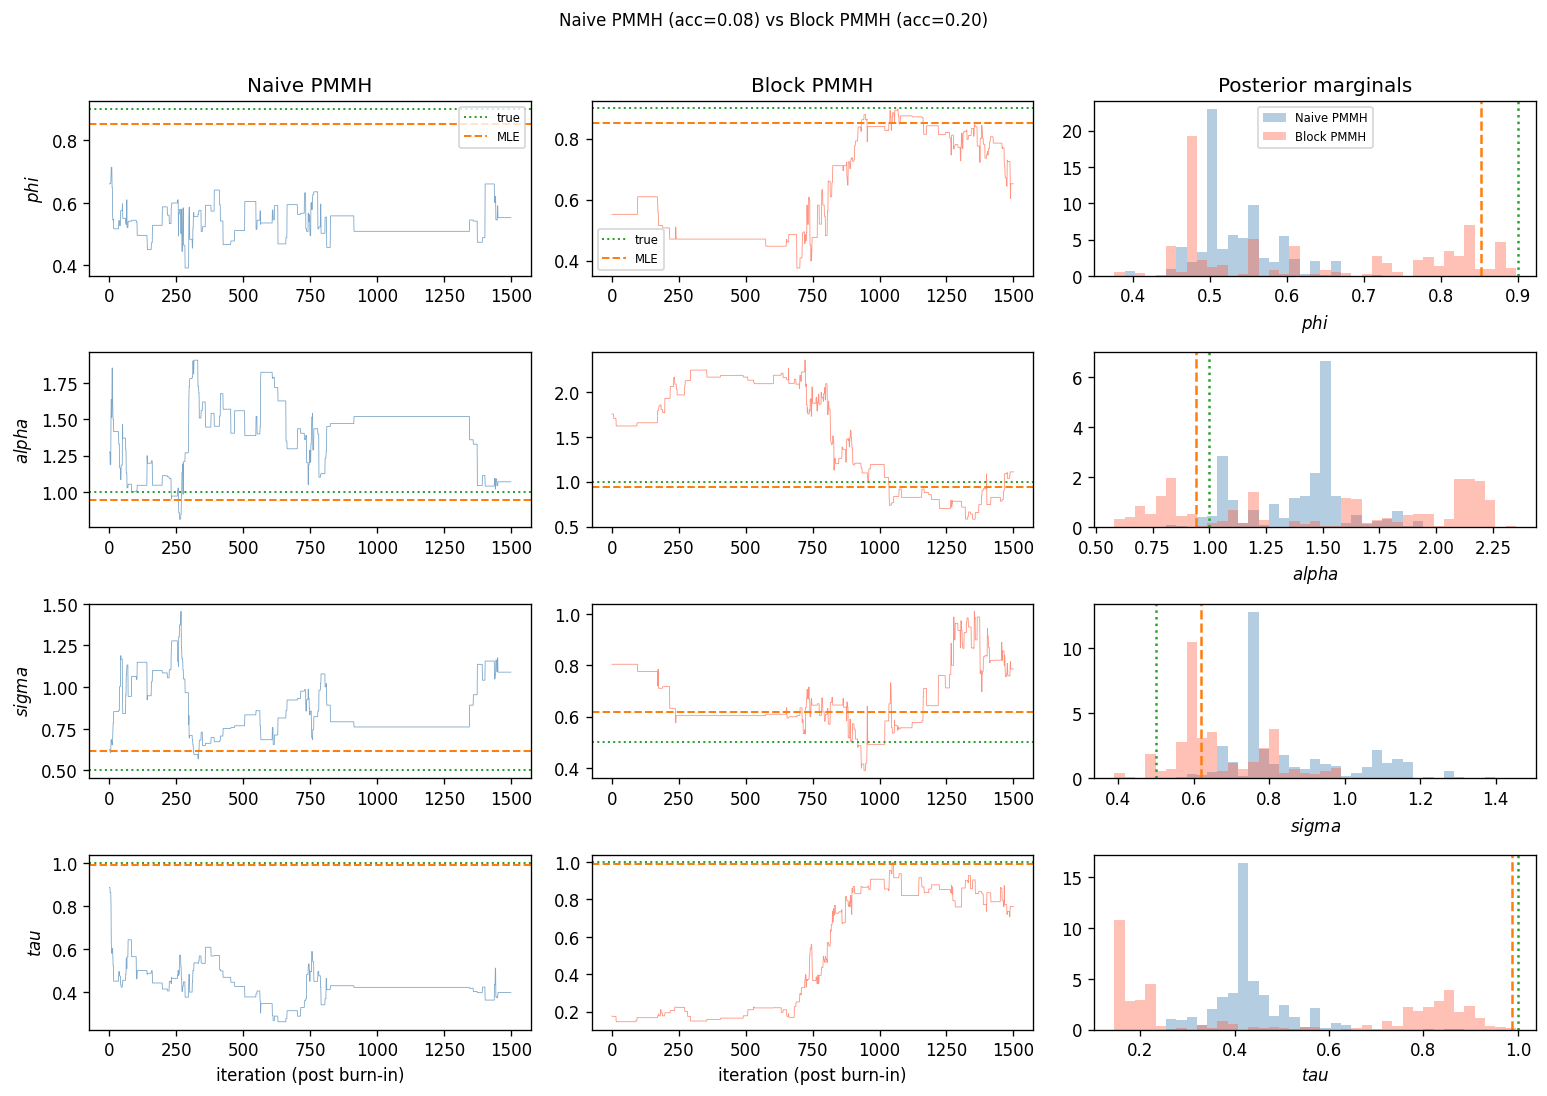

In [20]:
# ── trace plots and posterior comparison ──────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(13, 9))

for k, name in enumerate(model.params_dict.keys()):
    tv = TRUE_PARAMS[name]
    mv = mle_est[k]

    for col, (label, ch, color) in enumerate([
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]):
        ax = axes[k, col]
        ax.plot(ch[:, k], lw=0.5, color=color, alpha=0.7)
        ax.axhline(tv, color='C2', ls=':', lw=1.2, label='true' if k == 0 else None)
        ax.axhline(mv, color='C1', ls='--', lw=1.2, label='MLE' if k == 0 else None)
        ax.set_ylabel(f'${name}$' if col == 0 else '')
        if k == 0:
            ax.set_title(label)
            ax.legend(fontsize=7)

    ax_m = axes[k, 2]
    lo = min(constrained_n[:, k].min(), constrained_b[:, k].min())
    hi = max(constrained_n[:, k].max(), constrained_b[:, k].max())
    bins = np.linspace(lo, hi, 40)
    for label, ch, color in [
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]:
        ax_m.hist(ch[:, k], bins=bins, density=True, alpha=0.4, color=color, label=label)
    ax_m.axvline(tv, color='C2', ls=':', lw=1.5)
    ax_m.axvline(mv, color='C1', ls='--', lw=1.5)
    ax_m.set_xlabel(f'${name}$')
    if k == 0:
        ax_m.set_title('Posterior marginals')
        ax_m.legend(fontsize=7)

for col in range(2):
    axes[-1, col].set_xlabel('iteration (post burn-in)')
plt.suptitle(
    f'Naive PMMH (acc={acc_n.mean():.2f}) vs Block PMMH (acc={acc_b.mean():.2f})',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

---
## 4. Effect of N_particles on PMMH

The variance of the PF log-likelihood estimator scales as $O(1/N)$, which directly inflates the
posterior variance of the PMMH chain. We investigate:

- How posterior width and chain mixing depend on $N$
- How acceptance rate and ESS depend on $N$ (Question: How to tune resampling threshold?)
- How PMMH posterior means compare to the KF MLE baseline and true parameter values
- The **`alpha · sigma` identification issue**: because observations are
  $y_t = \alpha x_t + \epsilon_t$ and $x_t \sim \text{AR}(1)$ with noise $\sigma$, the product
  $\alpha \cdot \sigma$ is identified by the data but the individual factors may not be — a
  ridge in the log-likelihood surface. We visualize this and assess whether PMMH recovers
  the ridge or gets stuck.

In [21]:
N_VALS   = [50, 200, 500, 1000, 2000]
N_ITER_N = 1500
BURN_N   = 300
step_n   = np.array([0.06, 0.10, 0.06, 0.06])

sweep_results = {}

for N_p in N_VALS:
    m_sw     = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=11)
    pf_sw    = ParticleFilter(m_sw, N_p, obs, SystematicResampling(seed=N_p))
    pmmh_sw  = PMMH(m_sw, pf_sw, n_iter=N_ITER_N,
                    step_sizes=step_n,
                    theta0=result.unconstrained_params,
                    log_prior=log_prior, seed=N_p)
    print(f"  N={N_p:5d} ...", end='', flush=True)
    ch_sw, ll_sw, acc_sw = pmmh_sw.run()
    print(f"  acc={acc_sw.mean():.3f}")
    con_sw = m_sw.constrain_chain(ch_sw[BURN_N:])
    sweep_results[N_p] = {
        'chain_con': con_sw,
        'loglik':    ll_sw[BURN_N:],
        'acc_rate':  float(acc_sw.mean()),
        'post_mean': con_sw.mean(axis=0),
        'post_std':  con_sw.std(axis=0),
        'ess':       np.array([chain_ess(con_sw[:, k]) for k in range(4)]),
    }

print("Done.")

  N=   50 ...[501/1500]  theta = [ 0.4077985   0.31957734 -0.20207738 -0.04581904],  loglik = -499.27,  accept rate = 0.036
[1001/1500]  theta = [ 0.78347106  0.64302332 -0.38214675 -0.09015894],  loglik = -501.61,  accept rate = 0.023
PMMH.run  140.401s
  acc=0.027
  N=  200 ...[501/1500]  theta = [ 0.36013458  0.4288461  -0.22633218 -0.07102999],  loglik = -503.23,  accept rate = 0.116
[1001/1500]  theta = [ 0.64870526  0.74027596 -0.24597045 -0.1908599 ],  loglik = -501.39,  accept rate = 0.091
PMMH.run  548.666s
  acc=0.073
  N=  500 ...[501/1500]  theta = [ 0.32721966  0.36356841 -0.13156423 -0.08136496],  loglik = -502.24,  accept rate = 0.184
[1001/1500]  theta = [ 0.61169012  0.68975685 -0.18744142 -0.17978262],  loglik = -504.07,  accept rate = 0.152
PMMH.run  1359.939s
  acc=0.155
  N= 1000 ...[501/1500]  theta = [ 0.36153282  0.30663639 -0.11389004 -0.05838836],  loglik = -504.56,  accept rate = 0.150
[1001/1500]  theta = [ 0.64935113  0.86487621 -0.33986444 -0.1615255 ],  l

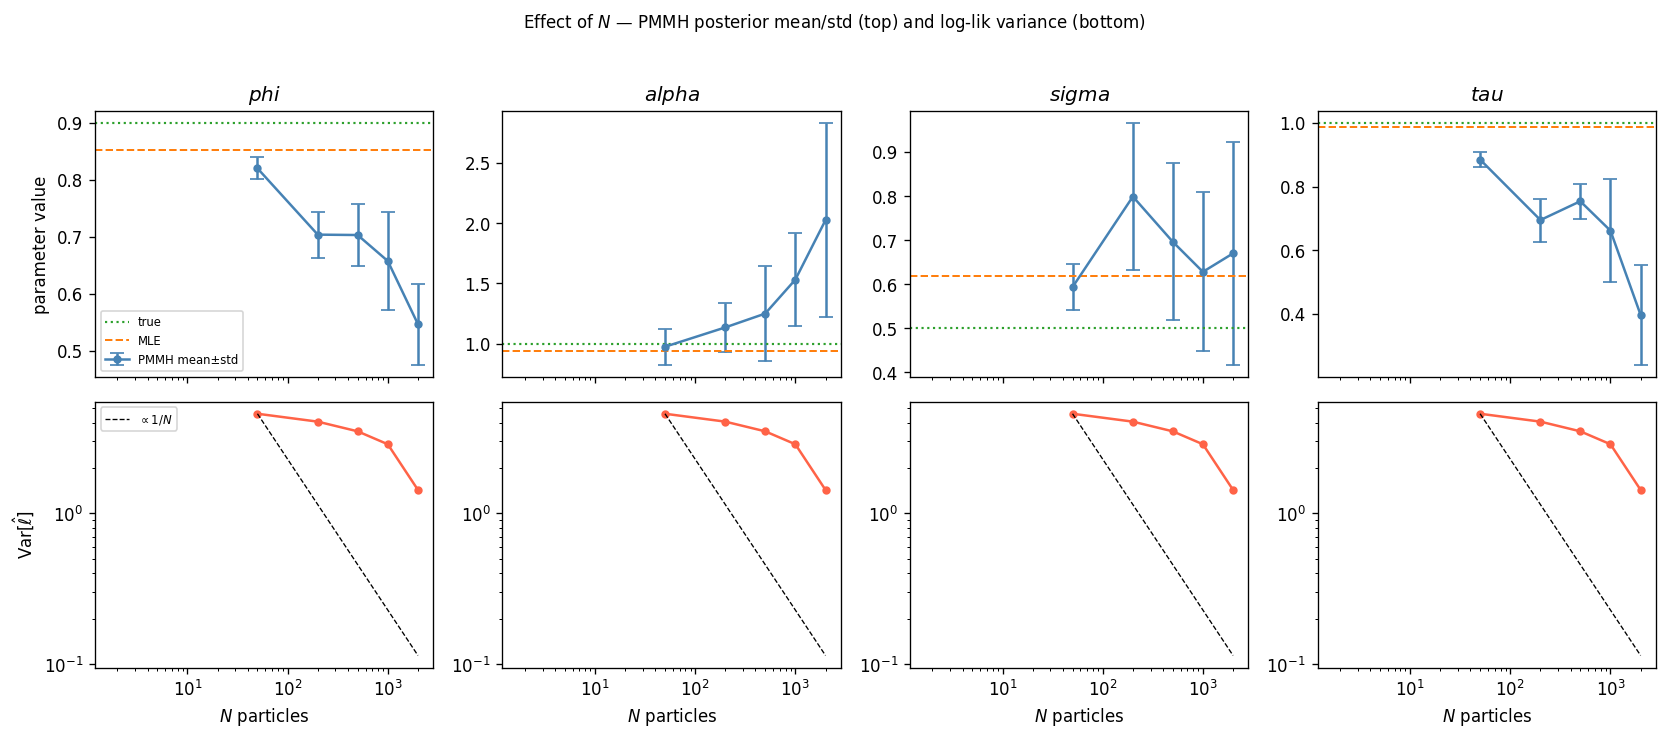

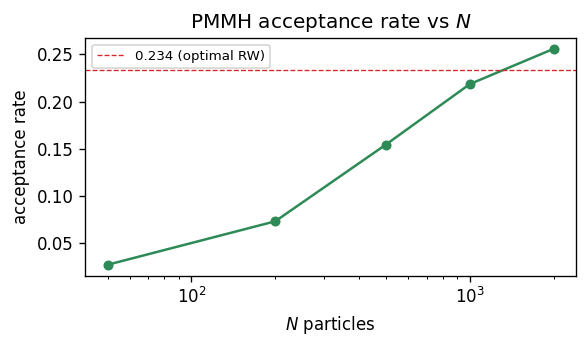

In [22]:
names_4 = list(model.params_dict.keys())
trues_4 = [TRUE_PARAMS[n] for n in names_4]
mle_con = list(result.constrained_params)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True)

for k, name in enumerate(names_4):
    tv    = trues_4[k]
    mv    = mle_con[k]
    means = np.array([sweep_results[N]['post_mean'][k] for N in N_VALS])
    stds  = np.array([sweep_results[N]['post_std'][k]  for N in N_VALS])

    ax_m = axes[0, k]
    ax_m.errorbar(N_VALS, means, yerr=stds, fmt='o-', color='steelblue',
                  capsize=4, ms=4, label='PMMH mean±std' if k == 0 else None)
    ax_m.axhline(tv, color='C2', ls=':', lw=1.3, label='true' if k == 0 else None)
    ax_m.axhline(mv, color='C1', ls='--', lw=1.2, label='MLE' if k == 0 else None)
    ax_m.set_title(f'${name}$')
    ax_m.set_xscale('log')
    if k == 0:
        ax_m.set_ylabel('parameter value')
        ax_m.legend(fontsize=7)

    # log-likelihood variance vs N (should scale as 1/N)
    ll_vars = np.array([sweep_results[N]['loglik'].var() + 1e-10 for N in N_VALS])
    scale_1N = float(ll_vars[0]) * N_VALS[0]
    ax_v = axes[1, k]
    ax_v.plot(N_VALS, ll_vars, 'o-', color='tomato', ms=4)
    ax_v.plot(N_VALS, [scale_1N / N for N in N_VALS], 'k--', lw=0.8,
              label=r'$\propto 1/N$' if k == 0 else None)
    ax_v.set_xscale('log')
    ax_v.set_yscale('log')
    ax_v.set_xlabel('$N$ particles')
    if k == 0:
        ax_v.set_ylabel(r'Var$[\hat{\ell}]$')
        ax_v.legend(fontsize=7)

plt.suptitle(
    r'Effect of $N$ — PMMH posterior mean/std (top) and log-lik variance (bottom)',
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

# ── acceptance rate vs N ──────────────────────────────────────────────────────
accs = [sweep_results[N]['acc_rate'] for N in N_VALS]
fig2, ax2 = plt.subplots(figsize=(5, 3))
ax2.plot(N_VALS, accs, 'o-', color='seagreen', ms=5)
ax2.set_xscale('log')
ax2.set_xlabel('$N$ particles')
ax2.set_ylabel('acceptance rate')
ax2.set_title('PMMH acceptance rate vs $N$')
ax2.axhline(0.234, color='C3', ls='--', lw=0.8, label='0.234 (optimal RW)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

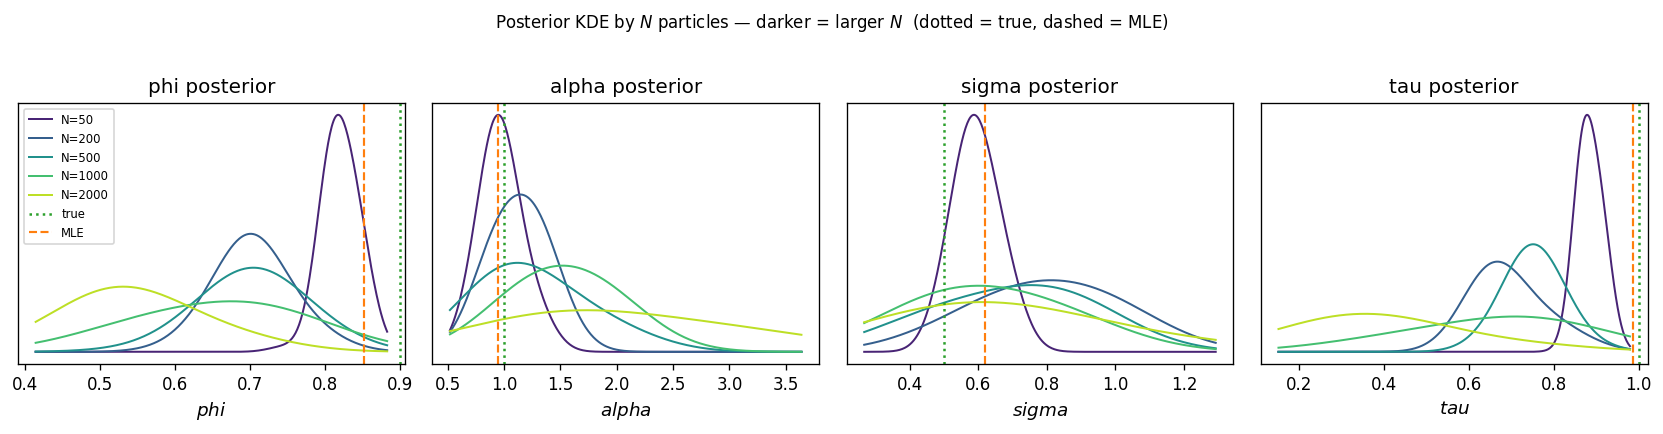

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
colors_N  = plt.cm.viridis(np.linspace(0.1, 0.9, len(N_VALS)))

for k, name in enumerate(names_4):
    ax = axes[k]
    tv = trues_4[k]
    mv = mle_con[k]

    all_samp = np.concatenate([sweep_results[N]['chain_con'][:, k] for N in N_VALS])
    lo = np.percentile(all_samp, 1)
    hi = np.percentile(all_samp, 99)
    margin = 0.08 * (hi - lo)
    xg = np.linspace(lo - margin, hi + margin, 400)

    for i, N_p in enumerate(N_VALS):
        samp = sweep_results[N_p]['chain_con'][:, k]
        kde  = KDE(samp)
        ax.plot(xg, kde.evaluate(xg), lw=1.2, color=colors_N[i],
                label=f'N={N_p}' if k == 0 else None)

    ax.axvline(tv, color='C2', ls=':', lw=1.5, label='true' if k == 0 else None)
    ax.axvline(mv, color='C1', ls='--', lw=1.3, label='MLE' if k == 0 else None)
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'{name} posterior')
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    r'Posterior KDE by $N$ particles — darker = larger $N$  (dotted = true, dashed = MLE)',
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

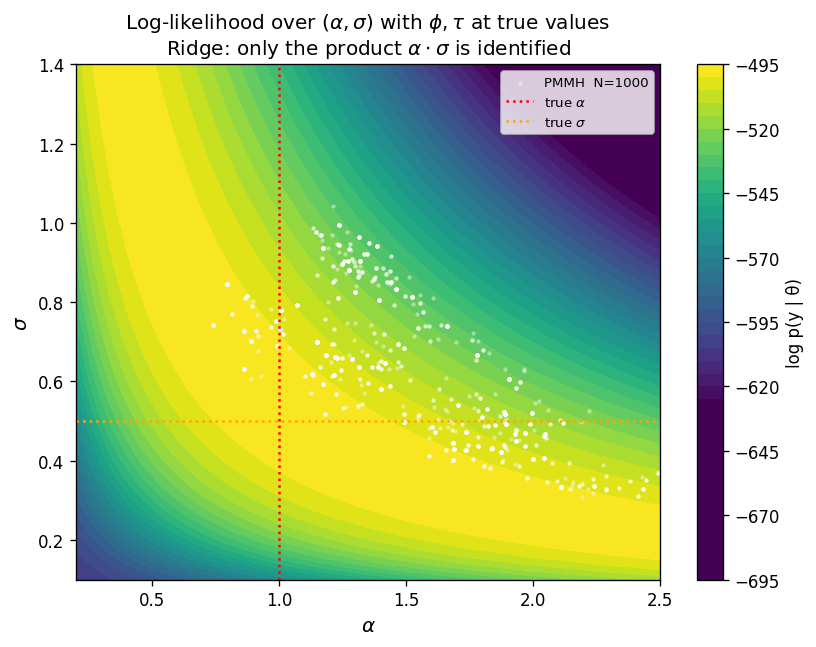

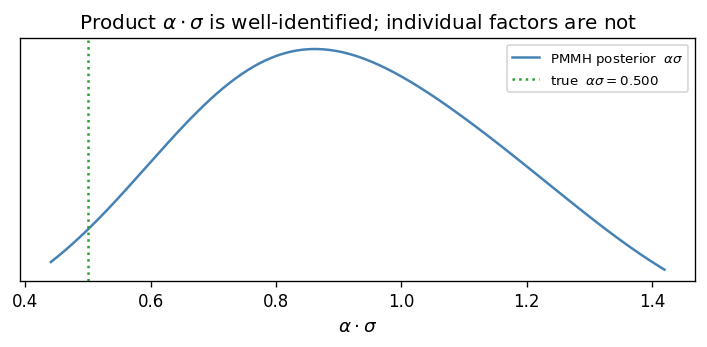

In [24]:
# ── 2-D log-likelihood surface over (alpha, sigma) ────────────────────────────
phi_fix = TRUE_PARAMS['phi']
tau_fix = TRUE_PARAMS['tau']
n_grid  = 70

alpha_grid = np.linspace(0.2, 2.5, n_grid)
sigma_grid = np.linspace(0.1, 1.4, n_grid)
AA, SS = np.meshgrid(alpha_grid, sigma_grid)
LL = np.full_like(AA, np.nan)

for i in range(n_grid):
    for j in range(n_grid):
        try:
            m_grid = SimpleLinearGaussianSSM(phi_fix, AA[i, j], SS[i, j], tau_fix)
            LL[i, j] = m_grid.log_likelihood(obs)
        except (ValueError, FloatingPointError):
            pass

vmin = np.nanpercentile(LL, 5)
vmax = np.nanmax(LL)

fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(AA, SS, LL, levels=40, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(cf, ax=ax, label='log p(y | θ)')

samp_ridge = sweep_results[1000]['chain_con']
ax.scatter(samp_ridge[:, 1], samp_ridge[:, 2], c='white', s=3, alpha=0.3,
           label='PMMH  N=1000')
ax.axvline(TRUE_PARAMS['alpha'], color='red',    ls=':', lw=1.5, label=r'true $\alpha$')
ax.axhline(TRUE_PARAMS['sigma'], color='orange', ls=':', lw=1.5, label=r'true $\sigma$')
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel(r'$\sigma$', fontsize=12)
ax.set_title(
    r'Log-likelihood over $(\alpha, \sigma)$ with $\phi, \tau$ at true values'
    '\n' r'Ridge: only the product $\alpha \cdot \sigma$ is identified'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── the identified quantity: alpha * sigma ────────────────────────────────────
prod_true = TRUE_PARAMS['alpha'] * TRUE_PARAMS['sigma']
prod_pmmh = samp_ridge[:, 1] * samp_ridge[:, 2]
kde_prod  = KDE(prod_pmmh)
xg = np.linspace(max(0.0, prod_pmmh.min() - 0.1), prod_pmmh.max() + 0.1, 300)

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.plot(xg, kde_prod.evaluate(xg), lw=1.5, color='steelblue',
         label=r'PMMH posterior  $\alpha\sigma$')
ax2.axvline(prod_true, color='C2', ls=':', lw=1.5,
            label=fr'true  $\alpha\sigma = {prod_true:.3f}$')
ax2.set_xlabel(r'$\alpha \cdot \sigma$', fontsize=11)
ax2.set_title(r'Product $\alpha \cdot \sigma$ is well-identified; individual factors are not')
ax2.legend(fontsize=8)
ax2.set_yticks([])
plt.tight_layout()
plt.show()

---
## 5. Effect of observation noise on parameter estimation

Higher observation noise $\tau$ reduces the signal available for identifying the latent process
parameters $(\phi, \sigma)$. We sweep `tau_true` and examine:

- MLE estimation error (bias and variance across MC trials) for each parameter
- PMMH posterior width as a function of `tau_true`
- Whether the signal-to-noise ratio $\sigma / \tau$ is a better predictor of estimation quality
  than $\tau$ alone
- Limits of recoverability: at what $\tau$ does parameter estimation become unreliable?

In [25]:
TAU_VALS    = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
N_MC_TAU    = 15
BASE_PARAMS = dict(phi=0.9, alpha=1.0, sigma=0.5)

tau_mle_results = {}
rng_tau = np.random.default_rng(321)

for tau_v in TAU_VALS:
    true_p    = {**BASE_PARAMS, 'tau': tau_v}
    estimates = {n: np.full(N_MC_TAU, np.nan) for n in ['phi', 'alpha', 'sigma', 'tau']}
    print(f"tau={tau_v:.2f} ", end='', flush=True)
    for trial in range(N_MC_TAU):
        seed_t = int(rng_tau.integers(0, 100000))
        m_t    = SimpleLinearGaussianSSM(**true_p, seed=seed_t)
        _, obs_trial, _ = m_t.generate_data(300)
        obs_trial = obs_trial.ravel()
        try:
            res_t = MLEEstimator(m_t, obs_trial, n_restarts=2, seed=seed_t).fit()
            for k, pname in enumerate(['phi', 'alpha', 'sigma', 'tau']):
                estimates[pname][trial] = list(res_t.constrained_params)[k]
        except Exception:
            pass
    tau_mle_results[tau_v] = estimates
    print(f"  phi={np.nanmean(estimates['phi']):.3f}  tau={np.nanmean(estimates['tau']):.3f}")

print("Done.")

tau=0.30 MLEEstimator.fit  0.062s
MLEEstimator.fit  0.053s
MLEEstimator.fit  0.046s
MLEEstimator.fit  0.065s
MLEEstimator.fit  0.064s
MLEEstimator.fit  0.055s
MLEEstimator.fit  0.068s
MLEEstimator.fit  0.050s
MLEEstimator.fit  0.050s
MLEEstimator.fit  0.086s
MLEEstimator.fit  0.047s
MLEEstimator.fit  0.047s
MLEEstimator.fit  0.048s
MLEEstimator.fit  0.058s
MLEEstimator.fit  0.122s
  phi=0.882  tau=0.292
tau=0.50 MLEEstimator.fit  0.055s
MLEEstimator.fit  0.060s
MLEEstimator.fit  0.048s
MLEEstimator.fit  0.058s
MLEEstimator.fit  0.044s
MLEEstimator.fit  0.048s
MLEEstimator.fit  0.048s
MLEEstimator.fit  0.049s
MLEEstimator.fit  0.043s
MLEEstimator.fit  0.045s
MLEEstimator.fit  0.044s
MLEEstimator.fit  0.049s
MLEEstimator.fit  0.046s
MLEEstimator.fit  0.053s
MLEEstimator.fit  0.049s
  phi=0.887  tau=0.500
tau=0.75 MLEEstimator.fit  0.060s
MLEEstimator.fit  0.050s
MLEEstimator.fit  0.051s
MLEEstimator.fit  0.050s
MLEEstimator.fit  0.051s
MLEEstimator.fit  0.044s
MLEEstimator.fit  0.076s
ML

In [26]:
TAU_PMMH_VALS = [0.5, 1.0, 2.0]
N_ITER_TAU    = 1500
N_PART_TAU    = 500
BURN_TAU      = 300
step_tau      = np.array([0.06, 0.10, 0.06, 0.06])

tau_pmmh_results = {}

for tau_v in TAU_PMMH_VALS:
    true_p = {**BASE_PARAMS, 'tau': tau_v}
    # generate a fresh dataset for this tau value
    m_gen  = SimpleLinearGaussianSSM(**true_p, seed=77)
    _, obs_tv, _ = m_gen.generate_data(300)
    obs_tv = obs_tv.ravel()
    # MLE warm start
    res_tv = MLEEstimator(SimpleLinearGaussianSSM(**true_p, seed=78), obs_tv,
                          n_restarts=2, seed=78).fit()
    theta0_tv = res_tv.unconstrained_params
    # PMMH
    m_tv   = SimpleLinearGaussianSSM(**true_p, seed=79)
    pf_tv  = ParticleFilter(m_tv, N_PART_TAU, obs_tv,
                             SystematicResampling(seed=int(tau_v * 100)))
    pmmh_tv = PMMH(m_tv, pf_tv, n_iter=N_ITER_TAU,
                   step_sizes=step_tau, theta0=theta0_tv,
                   log_prior=log_prior, seed=77)
    print(f"tau={tau_v:.1f} ...", end='', flush=True)
    ch_tv, _, acc_tv = pmmh_tv.run()
    print(f"  acc={acc_tv.mean():.3f}")
    tau_pmmh_results[tau_v] = {
        'chain_con': m_tv.constrain_chain(ch_tv[BURN_TAU:]),
        'acc':       float(acc_tv.mean()),
    }

print("Done.")

MLEEstimator.fit  0.054s
tau=0.5 ...[501/1500]  theta = [ 0.39857444  0.32581094 -0.15454431 -0.37091228],  loglik = -357.17,  accept rate = 0.088
[1001/1500]  theta = [ 0.7577923   0.63506242 -0.25539409 -0.77190174],  loglik = -359.36,  accept rate = 0.122
PMMH.run  1392.911s
  acc=0.142
MLEEstimator.fit  0.053s
tau=1.0 ...[501/1500]  theta = [ 0.41384763  0.36552738 -0.28566936 -0.02163303],  loglik = -490.19,  accept rate = 0.176
[1001/1500]  theta = [ 0.78589167  0.72481869 -0.53108808 -0.05863255],  loglik = -490.90,  accept rate = 0.169
PMMH.run  1400.092s
  acc=0.177
MLEEstimator.fit  0.078s
tau=2.0 ...[501/1500]  theta = [ 0.62794037  0.28697459 -0.36153447  0.22092067],  loglik = -654.42,  accept rate = 0.102
[1001/1500]  theta = [ 1.15648865  0.76724754 -0.73881213  0.40745989],  loglik = -656.33,  accept rate = 0.092
PMMH.run  1386.525s
  acc=0.147
Done.


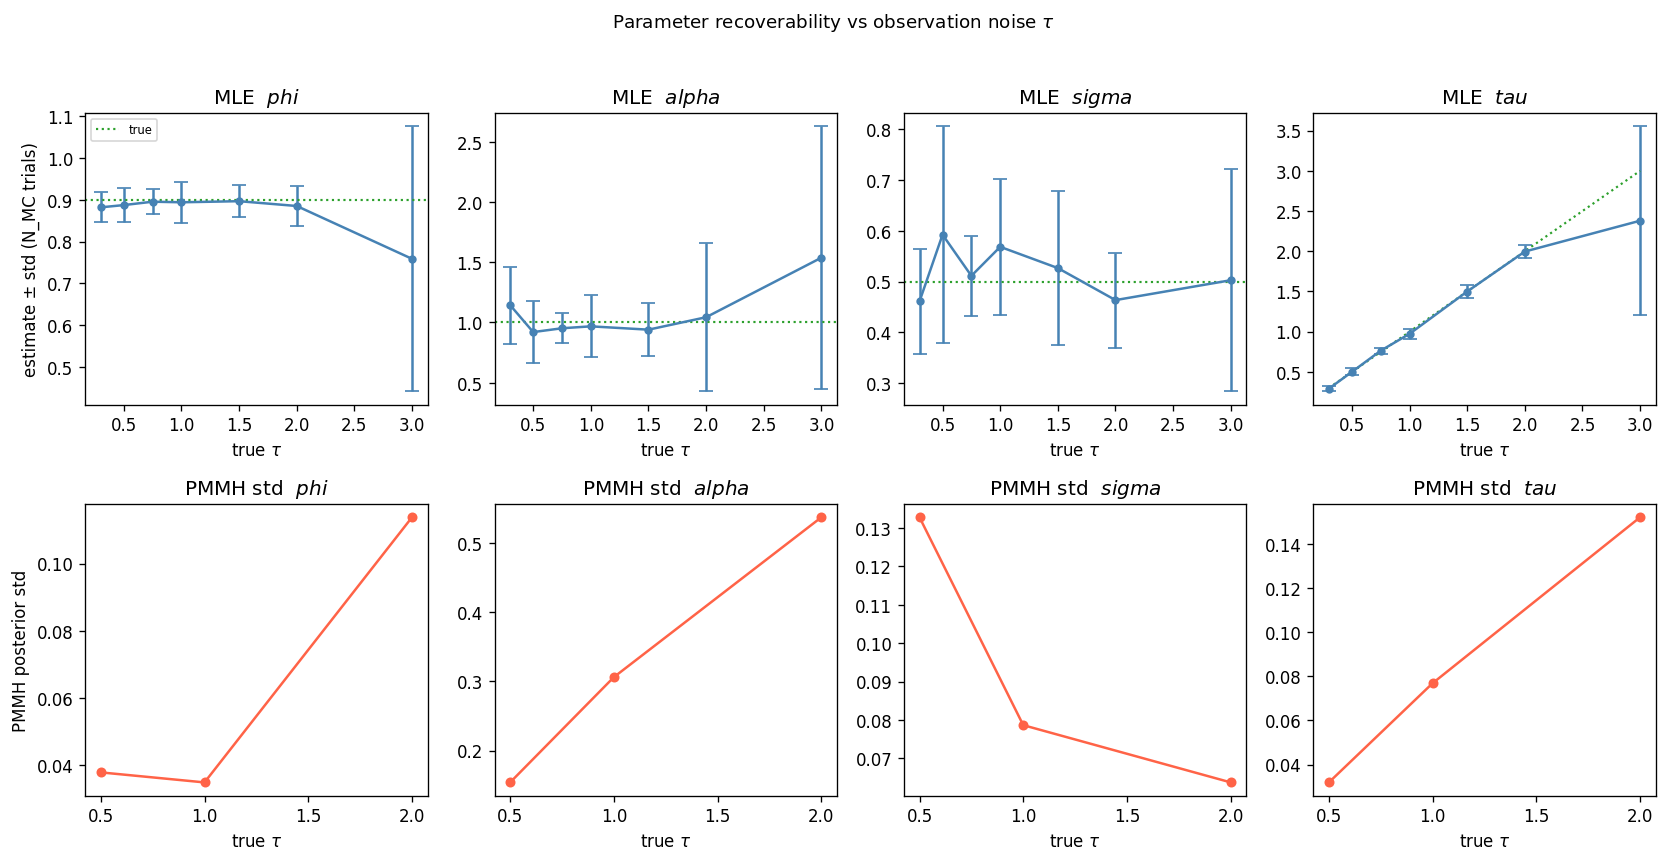

In [27]:
names_tau  = ['phi', 'alpha', 'sigma', 'tau']
true_fixed = {'phi': 0.9, 'alpha': 1.0, 'sigma': 0.5}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for k, name in enumerate(names_tau):
    mle_means = [np.nanmean(tau_mle_results[tv][name]) for tv in TAU_VALS]
    mle_stds  = [np.nanstd(tau_mle_results[tv][name])  for tv in TAU_VALS]

    ax_m = axes[0, k]
    ax_m.errorbar(TAU_VALS, mle_means, yerr=mle_stds,
                  fmt='o-', color='steelblue', capsize=4, ms=4)
    if name != 'tau':
        ax_m.axhline(true_fixed[name], color='C2', ls=':', lw=1.3,
                     label='true' if k == 0 else None)
    else:
        ax_m.plot(TAU_VALS, TAU_VALS, color='C2', ls=':', lw=1.3,
                  label='true' if k == 0 else None)
    ax_m.set_title(f'MLE  ${name}$')
    ax_m.set_xlabel(r'true $\tau$')
    if k == 0:
        ax_m.set_ylabel('estimate ± std (N_MC trials)')
        ax_m.legend(fontsize=7)

    pmmh_stds = [tau_pmmh_results[tv]['chain_con'][:, k].std() for tv in TAU_PMMH_VALS]
    ax_s = axes[1, k]
    ax_s.plot(TAU_PMMH_VALS, pmmh_stds, 'o-', color='tomato', ms=5)
    ax_s.set_xlabel(r'true $\tau$')
    ax_s.set_title(f'PMMH std  ${name}$')
    if k == 0:
        ax_s.set_ylabel('PMMH posterior std')

plt.suptitle(r'Parameter recoverability vs observation noise $\tau$', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. Model misspecification

We fit a `SimpleLinearGaussianSSM` (Gaussian noise, AR(1) latent) to data generated from:
- `LinearTSSM` — same AR(1) structure but with t-distributed process noise (heavy tails)
- `LinearARMASSM` — ARMA(1,3) latent process, richer autocorrelation structure

For each case we examine:
- MLE estimates under the misspecified model — which parameters absorb the specification error?
- PMMH posteriors under misspecification — does the posterior collapse or widen?
- Goodness-of-fit diagnostics: residual autocorrelation, filtered state RMSE, log-likelihood gap
  between the misspecified MLE and the correct model's true log-likelihood

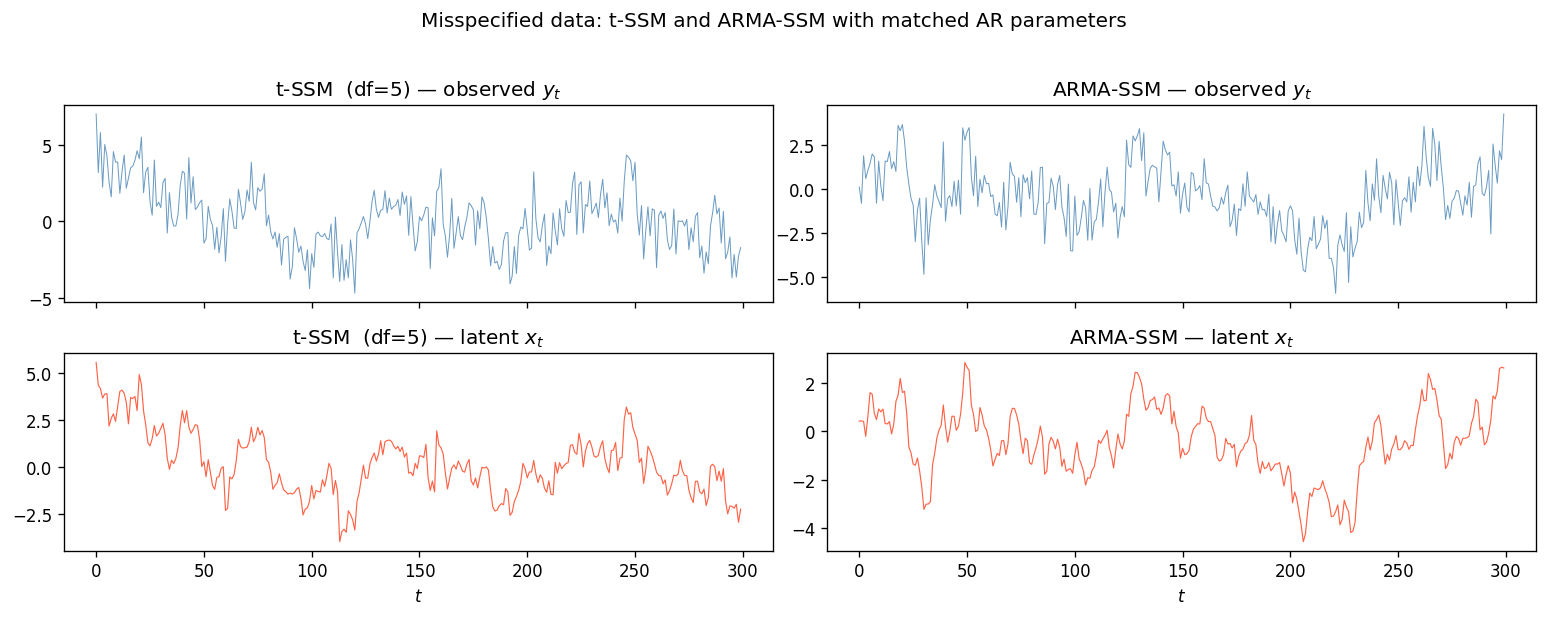

In [28]:
MISSPEC_T    = 300
MISSPEC_SEED = 55
M_PHI, M_ALPHA, M_SIGMA, M_TAU = 0.9, 1.0, 0.5, 1.0

# ── t-distributed process noise ───────────────────────────────────────────────
t_model  = LinearTSSM(phi=M_PHI, alpha=M_ALPHA, sigma=M_SIGMA, tau=M_TAU,
                      df=5, seed=MISSPEC_SEED)
states_t_raw, obs_t_raw, _ = t_model.generate_data(MISSPEC_T)
states_t = states_t_raw.ravel()
obs_t    = obs_t_raw.ravel()

# ── ARMA(1,3) latent process ──────────────────────────────────────────────────
arma_model = LinearARMASSM(phi=M_PHI, alpha=M_ALPHA, c=0,
                            theta_1=0.3, theta_2=0.1, theta_3=0.05,
                            sigma=M_SIGMA, tau=M_TAU, seed=MISSPEC_SEED)
states_a_raw, obs_a_raw, _ = arma_model.generate_data(MISSPEC_T)
states_a = states_a_raw[:, 0]   # x_t component of the 4-D augmented state
obs_a    = obs_a_raw.ravel()

fig, axes = plt.subplots(2, 2, figsize=(13, 5), sharex=True)
for col, (label, ys, xs) in enumerate([
    ('t-SSM  (df=5)',  obs_t, states_t),
    ('ARMA-SSM',       obs_a, states_a),
]):
    axes[0, col].plot(ys, lw=0.6, color='steelblue', alpha=0.8)
    axes[0, col].set_title(f'{label} — observed $y_t$')
    axes[1, col].plot(xs, lw=0.7, color='tomato')
    axes[1, col].set_title(f'{label} — latent $x_t$')
    axes[1, col].set_xlabel('$t$')

plt.suptitle('Misspecified data: t-SSM and ARMA-SSM with matched AR parameters', y=1.02)
plt.tight_layout()
plt.show()

MLEEstimator.fit  0.085s
MLE fit to t-SSM data:
MLEResult  loglik=-537.3423  converged  n_evals=65
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.952344      0.024899
  alpha                 0.885618             —
  sigma                 0.652450             —
  tau                   1.148749      0.067868


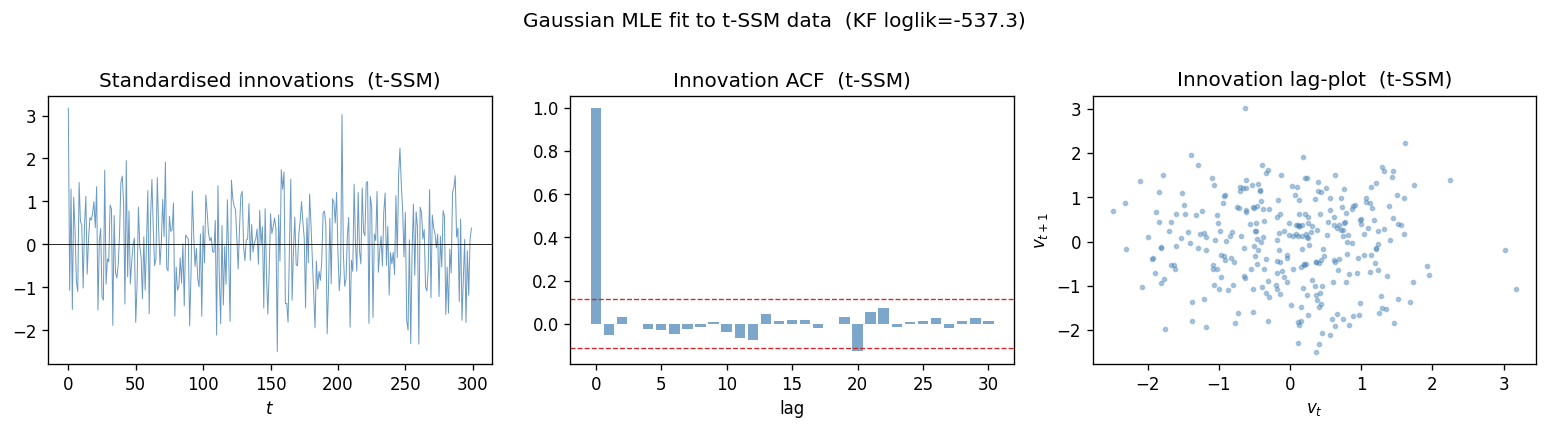

In [29]:
# ── fit SimpleLinearGaussianSSM (MLE) to t-SSM data ───────────────────────────
gauss_t   = SimpleLinearGaussianSSM(M_PHI, M_ALPHA, M_SIGMA, M_TAU, seed=99)
mle_t     = MLEEstimator(gauss_t, obs_t, n_restarts=3, seed=0)
result_t  = mle_t.fit()
mle_t.compute_std_errors()
print("MLE fit to t-SSM data:")
print(result_t.summary())

# ── Kalman filter under misspecified model → innovation diagnostics ────────────
phi_t_m, alpha_t_m, sigma_t_m, tau_t_m = result_t.constrained_params
lg_t = LinearGaussianSSM(
    a=np.array([[phi_t_m]]), c=np.array([[alpha_t_m]]),
    q=np.array([[sigma_t_m**2]]), r=np.array([[tau_t_m**2]]),
)
kf_t = KalmanFilter(lg_t, obs_t)
filt_t, _, kf_loglik_t = kf_t.run_filter()

innovations_t = kf_t.innovations.ravel()
inn_std_t     = np.sqrt(kf_t.innovation_covs[:, 0, 0])
xc_t  = innovations_t - innovations_t.mean()
var_t = xc_t.var()
acf_inn_t = (np.correlate(xc_t, xc_t, 'full')[MISSPEC_T - 1:] / (MISSPEC_T * var_t)
             if var_t > 0 else np.zeros(MISSPEC_T))

max_lag = 30
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(innovations_t / inn_std_t, lw=0.6, color='steelblue', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Standardised innovations  (t-SSM)')
axes[0].set_xlabel('$t$')

axes[1].bar(range(max_lag + 1), acf_inn_t[:max_lag + 1], color='steelblue', alpha=0.7)
axes[1].axhline( 1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].set_title('Innovation ACF  (t-SSM)')
axes[1].set_xlabel('lag')

axes[2].scatter(innovations_t[:-1] / inn_std_t[:-1],
                innovations_t[1:]  / inn_std_t[1:],
                s=6, alpha=0.4, color='steelblue')
axes[2].set_xlabel('$v_t$')
axes[2].set_ylabel('$v_{t+1}$')
axes[2].set_title('Innovation lag-plot  (t-SSM)')

plt.suptitle(f'Gaussian MLE fit to t-SSM data  (KF loglik={kf_loglik_t:.1f})', y=1.01)
plt.tight_layout()
plt.show()

MLEEstimator.fit  0.076s
MLE fit to ARMA-SSM data:
MLEResult  loglik=-510.9278  converged  n_evals=60
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.929663      0.026654
  alpha                 1.073504    267.684050
  sigma                 0.537271    133.978049
  tau                   1.031319      0.061667

True ARMA KF loglik:          -511.7
Misspecified Gauss MLE loglik: -510.9
Log-lik gap:                   0.7


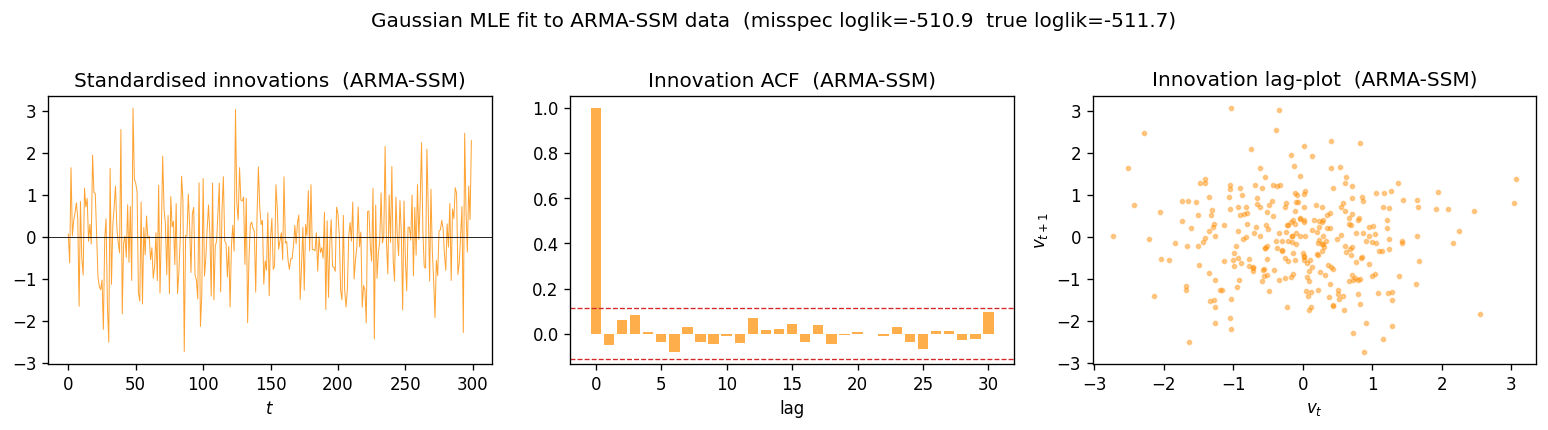

In [30]:
# ── fit SimpleLinearGaussianSSM (MLE) to ARMA-SSM data ────────────────────────
gauss_a   = SimpleLinearGaussianSSM(M_PHI, M_ALPHA, M_SIGMA, M_TAU, seed=99)
mle_a     = MLEEstimator(gauss_a, obs_a, n_restarts=3, seed=0)
result_a  = mle_a.fit()
mle_a.compute_std_errors()
print("MLE fit to ARMA-SSM data:")
print(result_a.summary())

# ── True ARMA log-likelihood via LinearGaussianSSM companion form ─────────────
# State s_t = [x_t, nu_t, nu_{t-1}, nu_{t-2}]
# x_t = c + phi*x_{t-1} + th1*nu_{t-1} + th2*nu_{t-2} + th3*nu_{t-3} + nu_t
phi_r  = arma_model.phi
th1, th2, th3 = arma_model.theta_1, arma_model.theta_2, arma_model.theta_3
c_r    = arma_model.c
sig_r  = arma_model.sigma
tau_r  = arma_model.tau
alp_r  = arma_model.alpha

A_arma = np.array([[phi_r, th1,  th2,  th3],
                   [0,     0,    0,    0  ],
                   [0,     1,    0,    0  ],
                   [0,     0,    1,    0  ]])
B_arma = np.array([1.0, 1.0, 0.0, 0.0])       # nu_t enters x_t and the nu_t slot
Q_arma = sig_r**2 * np.outer(B_arma, B_arma)
C_arma = np.array([[alp_r, 0, 0, 0]])
R_arma = np.array([[tau_r**2]])
b_arma = np.array([c_r, 0.0, 0.0, 0.0])

lg_arma_true     = LinearGaussianSSM(a=A_arma, c=C_arma, q=Q_arma, r=R_arma, b=b_arma)
true_loglik_arma = lg_arma_true.log_likelihood(obs_a)
print(f"\nTrue ARMA KF loglik:          {true_loglik_arma:.1f}")
print(f"Misspecified Gauss MLE loglik: {result_a.loglik:.1f}")
print(f"Log-lik gap:                   {result_a.loglik - true_loglik_arma:.1f}")

# ── Kalman filter under misspecified model → innovation diagnostics ────────────
phi_a_m, alpha_a_m, sigma_a_m, tau_a_m = result_a.constrained_params
lg_a = LinearGaussianSSM(
    a=np.array([[phi_a_m]]), c=np.array([[alpha_a_m]]),
    q=np.array([[sigma_a_m**2]]), r=np.array([[tau_a_m**2]]),
)
kf_a = KalmanFilter(lg_a, obs_a)
filt_a, _, kf_loglik_a = kf_a.run_filter()

innovations_a = kf_a.innovations.ravel()
inn_std_a     = np.sqrt(kf_a.innovation_covs[:, 0, 0])
xc_a  = innovations_a - innovations_a.mean()
var_a = xc_a.var()
acf_inn_a = (np.correlate(xc_a, xc_a, 'full')[MISSPEC_T - 1:] / (MISSPEC_T * var_a)
             if var_a > 0 else np.zeros(MISSPEC_T))

max_lag = 30
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(innovations_a / inn_std_a, lw=0.6, color='darkorange', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Standardised innovations  (ARMA-SSM)')
axes[0].set_xlabel('$t$')

axes[1].bar(range(max_lag + 1), acf_inn_a[:max_lag + 1], color='darkorange', alpha=0.7)
axes[1].axhline( 1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].set_title('Innovation ACF  (ARMA-SSM)')
axes[1].set_xlabel('lag')

axes[2].scatter(innovations_a[:-1] / inn_std_a[:-1],
                innovations_a[1:]  / inn_std_a[1:],
                s=6, alpha=0.4, color='darkorange')
axes[2].set_xlabel('$v_t$')
axes[2].set_ylabel('$v_{t+1}$')
axes[2].set_title('Innovation lag-plot  (ARMA-SSM)')

plt.suptitle(
    f'Gaussian MLE fit to ARMA-SSM data  '
    f'(misspec loglik={result_a.loglik:.1f}  true loglik={true_loglik_arma:.1f})',
    y=1.01,
)
plt.tight_layout()
plt.show()

                                           t-SSM        ARMA-SSM
──────────────────────────────────────────────────────────────────
Misspec Gauss MLE loglik                  -537.3          -510.9
True model loglik                         -545.8          -511.7
Log-lik gap (misspec − true)                 8.5             0.7
──────────────────────────────────────────────────────────────────
bias: phi                                +0.0523         +0.0297
bias: alpha                              -0.1144         +0.0735
bias: sigma                              +0.1525         +0.0373
bias: tau                                +0.1487         +0.0313
──────────────────────────────────────────────────────────────────
Innovation ACF lag-1                     -0.0502         -0.0518


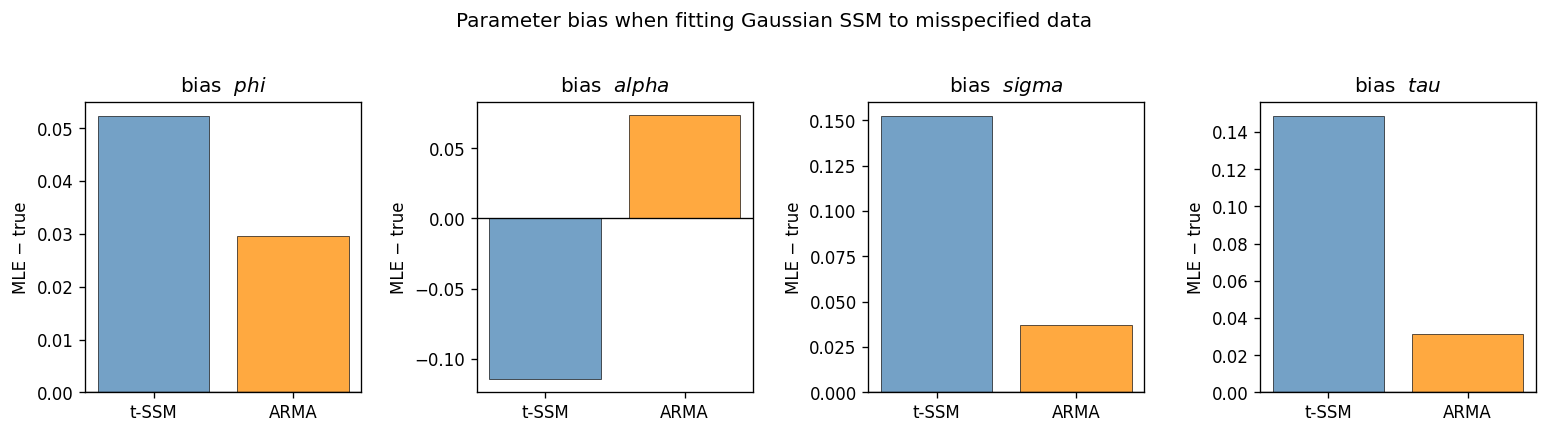

In [31]:
# ── PF estimate of true t-SSM log-likelihood ─────────────────────────────────
# p(y | θ_t, t-model) is intractable in closed form; estimate with a PF.
t_model_pf = LinearTSSM(phi=M_PHI, alpha=M_ALPHA, sigma=M_SIGMA, tau=M_TAU, df=5, seed=0)
pf_t_ref   = ParticleFilter(t_model_pf, 2000, obs_t, SystematicResampling(seed=0))
_, _, _, _, ll_t_true_pf = pf_t_ref.run_filter()

print(f"{'':32s}  {'t-SSM':>14}  {'ARMA-SSM':>14}")
print("─" * 66)
print(f"{'Misspec Gauss MLE loglik':<32}  {result_t.loglik:>14.1f}  {result_a.loglik:>14.1f}")
print(f"{'True model loglik':<32}  {ll_t_true_pf:>14.1f}  {true_loglik_arma:>14.1f}")
print(f"{'Log-lik gap (misspec − true)':<32}  {result_t.loglik - ll_t_true_pf:>14.1f}  {result_a.loglik - true_loglik_arma:>14.1f}")
print("─" * 66)
true_p_ref = [M_PHI, M_ALPHA, M_SIGMA, M_TAU]
for k, pname in enumerate(['phi', 'alpha', 'sigma', 'tau']):
    tv = true_p_ref[k]
    mt = list(result_t.constrained_params)[k]
    ma = list(result_a.constrained_params)[k]
    print(f"{'bias: ' + pname:<32}  {mt - tv:>+14.4f}  {ma - tv:>+14.4f}")
print("─" * 66)
print(f"{'Innovation ACF lag-1':<32}  {acf_inn_t[1]:>14.4f}  {acf_inn_a[1]:>14.4f}")

# ── parameter bias bar chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for k, (ax, pname) in enumerate(zip(axes, ['phi', 'alpha', 'sigma', 'tau'])):
    tv = true_p_ref[k]
    mt = list(result_t.constrained_params)[k]
    ma = list(result_a.constrained_params)[k]
    ax.bar(['t-SSM', 'ARMA'], [mt - tv, ma - tv],
           color=['steelblue', 'darkorange'], alpha=0.75, edgecolor='k', linewidth=0.5)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'bias  ${pname}$')
    ax.set_ylabel('MLE − true')

plt.suptitle('Parameter bias when fitting Gaussian SSM to misspecified data', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Regime-switching model estimation

Markov-switching state-space models combine a discrete hidden Markov chain
$s_t \in \{0, \ldots, K-1\}$ with per-regime linear Gaussian dynamics.
The marginal likelihood over all $K^T$ possible regime sequences is intractable,
which rules out direct KF MLE.

We compare three approaches on a 2-regime model where the regimes differ only in
process noise variance (low-volatility vs high-volatility state):

| Method | Likelihood | Notes |
|--------|-----------|-------|
| Naive PMMH | PF log-lik (unbiased) | Joint proposal over all parameters |
| Block PMMH | PF log-lik (unbiased) | Transition matrix and per-regime params in separate blocks |
| Kim filter MLE | Approximate Kim log-lik | Deterministic, fast; bias from the collapse approximation |

True transition matrix: $P_{00}=0.95$, $P_{11}=0.90$ (persistent regimes).

RegimeSwitchingSSM
  Regime-switching linear Gaussian SSM (No parameters shared)
  State dim: 1,  Obs dim: 1,  Regimes: 2
  Latent state: (x_t, s_t)  where s_t in {0, ..., 1}
  Transition:  x_t | s_t ~ N(A_{s_t} x_{t-1},  Q_{s_t})
  Observation: y_t | s_t ~ N(C_{s_t} x_t,         R_{s_t})
  Regime:      P(s_t = j | s_{t-1} = i) = P_ij
  Regime transition matrix:
[[0.95 0.05]
 [0.1  0.9 ]]
  Stationary regime probs: [0.66666667 0.33333333]
Fraction in regime 1: 0.310  (stationary: 0.333)


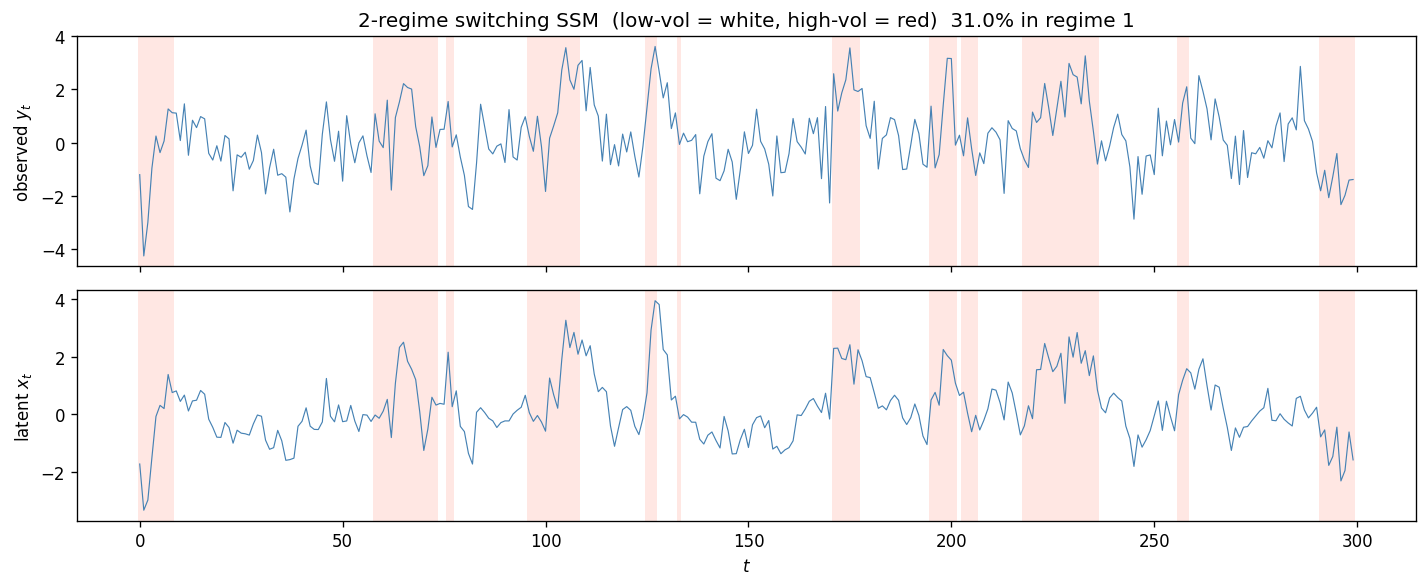

In [32]:
# ── 2-regime switching model: setup and data generation ───────────────────────
from models.regime_switching import RegimeSwitchingSSM
from estimation.kim_filter import KimFilter

# Regime 0: low-volatility  |  Regime 1: high-volatility
phi_r  = 0.8
A_list = [np.array([[phi_r]]), np.array([[phi_r]])]
C_list = [np.array([[1.0]]),   np.array([[1.0]])]
Q_list = [np.array([[0.25]]),  np.array([[1.00]])]   # σ² per regime
R_list = [np.array([[0.50]]),  np.array([[0.50]])]   # shared obs noise

P_true_rs = np.array([[0.95, 0.05],
                      [0.10, 0.90]])

rs_model = RegimeSwitchingSSM(A_list, C_list, Q_list, R_list, P_true_rs, seed=42)
print(rs_model.describe())

# ── generate data via explicit loop ───────────────────────────────────────────
# (base generate_data is incompatible: sample_initial_distribution returns (x, regime))
T_RS       = 300
states_rs  = np.zeros((T_RS, rs_model.state_dim))
regimes_rs = np.zeros(T_RS, dtype=int)
obs_rs     = np.zeros(T_RS)

x0, r0 = rs_model.sample_initial_distribution()
states_rs[0]  = x0
regimes_rs[0] = r0
obs_rs[0]     = rs_model.observation(x0, r0).ravel()[0]

for t in range(1, T_RS):
    r_prev        = regimes_rs[t - 1]
    r_t           = rs_model.rng.choice(rs_model.n_regimes, p=P_true_rs[r_prev])
    x_t           = rs_model.transition(states_rs[t - 1], r_t)
    obs_rs[t]     = rs_model.observation(x_t, r_t).ravel()[0]
    states_rs[t]  = x_t
    regimes_rs[t] = r_t

pct_r1 = (regimes_rs == 1).mean()
print(f"Fraction in regime 1: {pct_r1:.3f}  "
      f"(stationary: {rs_model.regime_probabilities_stationary[1]:.3f})")

# ── plot with regime-coloured background ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, vals, lbl in [(ax1, obs_rs, 'observed $y_t$'),
                       (ax2, states_rs[:, 0], 'latent $x_t$')]:
    ax.plot(vals, lw=0.7, color='steelblue', zorder=2)
    ax.set_ylabel(lbl)
    for t in range(T_RS):
        if regimes_rs[t] == 1:
            ax.axvspan(t - 0.5, t + 0.5, color='tomato', alpha=0.15, lw=0)

ax2.set_xlabel('$t$')
ax1.set_title(f'2-regime switching SSM  (low-vol = white, high-vol = red)  '
              f'{pct_r1*100:.1f}% in regime 1')
plt.tight_layout()
plt.show()

In [33]:
# ── PMMH for the regime-switching model — future work ─────────────────────────
# Running PMMH on RegimeSwitchingSSM requires two additions:
#
#   1. constrain_params / unconstrain_params on RegimeSwitchingSSM:
#      e.g. row-softmax for each row of the transition matrix P,
#           log transforms for per-regime diagonal Q and R variances.
#
#   2. An augmented particle state that jointly tracks (x_t, s_t).
#      The transition step must first sample a new regime from P[s_{t-1}, :],
#      then sample x_t | s_t, x_{t-1} from the per-regime Gaussian.
#      The observation density is p(y_t | x_t, s_t).
#
# Once those are in place, naive and block PMMH follow the same pattern as
# Sections 2-3.  The Kim filter approach in the next cell is available now
# as a fast, deterministic alternative for state filtering and approximate MLE.
print("PMMH for RegimeSwitchingSSM: requires constrain/unconstrain_params + "
      "regime-augmented PF state.  See comments above.  Proceeding to Kim filter.")

PMMH for RegimeSwitchingSSM: requires constrain/unconstrain_params + regime-augmented PF state.  See comments above.  Proceeding to Kim filter.


KimFilter.run_filter  0.062s
Kim approximate log-likelihood:   -445.22
Filtered regime probs (last step): [0.7566 0.2434]


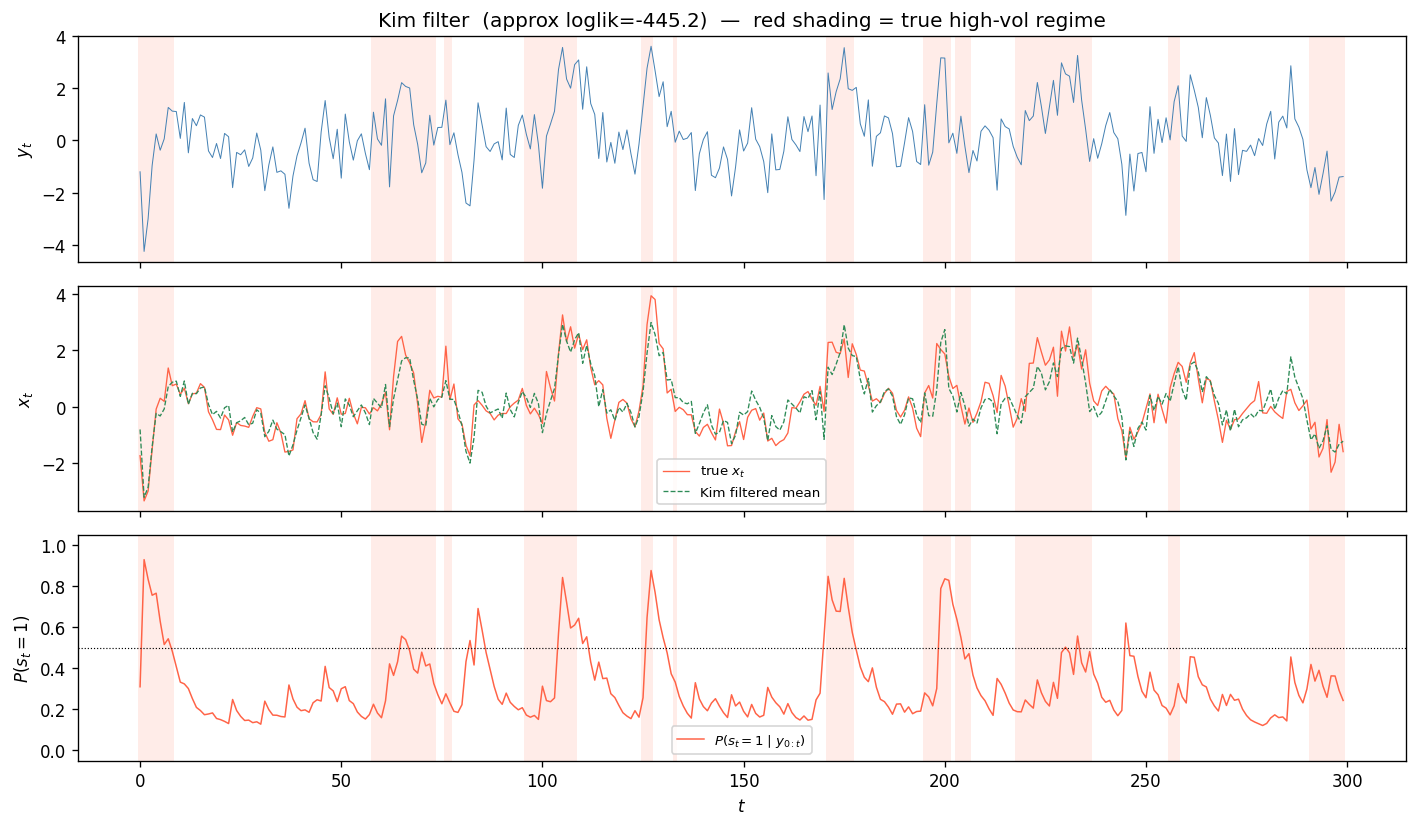

In [34]:
# ── Kim filter on the 2-regime switching model ────────────────────────────────
kf_kim = KimFilter(rs_model, obs_rs)
filtered_means_km, filtered_probs_km, loglik_km = kf_kim.run_filter()

print(f"Kim approximate log-likelihood:   {loglik_km:.2f}")
print(f"Filtered regime probs (last step): {np.round(filtered_probs_km[-1], 4)}")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(obs_rs, lw=0.6, color='steelblue', zorder=2)
axes[0].set_ylabel('$y_t$')

axes[1].plot(states_rs[:, 0],        lw=0.8, color='tomato',
             label='true $x_t$', zorder=2)
axes[1].plot(filtered_means_km[:, 0], lw=0.8, color='seagreen', ls='--',
             label='Kim filtered mean', zorder=3)
axes[1].set_ylabel('$x_t$')
axes[1].legend(fontsize=8)

axes[2].plot(filtered_probs_km[:, 1], lw=0.9, color='tomato',
             label=r'$P(s_t = 1 \mid y_{0:t})$')
axes[2].axhline(0.5, color='k', ls=':', lw=0.7)
axes[2].set_ylabel(r'$P(s_t=1)$')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(fontsize=8)
axes[2].set_xlabel('$t$')

# shade true regime-1 periods on all panels
for ax in axes:
    for t in range(T_RS):
        if regimes_rs[t] == 1:
            ax.axvspan(t - 0.5, t + 0.5, color='tomato', alpha=0.12, lw=0)

axes[0].set_title(
    f'Kim filter  (approx loglik={loglik_km:.1f})  —  red shading = true high-vol regime'
)
plt.tight_layout()
plt.show()

State estimation RMSE:          0.5094
Regime classification accuracy: 0.750

Confusion matrix (predicted \ true):
              true-0   true-1
  pred-0        195       63
  pred-1         12       30
  Precision: 0.714   Recall: 0.323


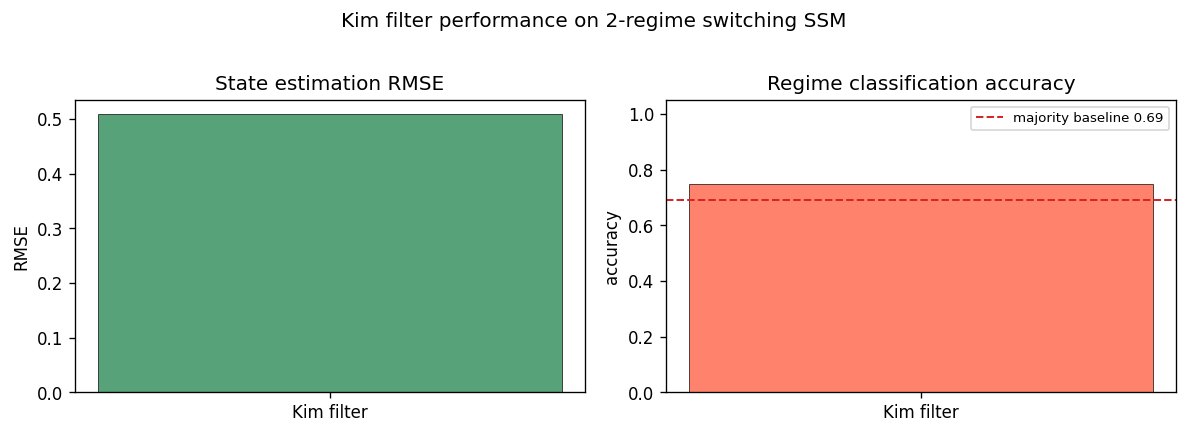

In [35]:
# ── Kim filter accuracy ───────────────────────────────────────────────────────
x_true_rs   = states_rs[:, 0]
rmse_kim    = rmse(x_true_rs, filtered_means_km[:, 0])
regime_pred = (filtered_probs_km[:, 1] > 0.5).astype(int)
acc_kim     = float(np.mean(regime_pred == regimes_rs))

tp = int(np.sum((regime_pred == 1) & (regimes_rs == 1)))
tn = int(np.sum((regime_pred == 0) & (regimes_rs == 0)))
fp = int(np.sum((regime_pred == 1) & (regimes_rs == 0)))
fn = int(np.sum((regime_pred == 0) & (regimes_rs == 1)))
prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')

print(f"State estimation RMSE:          {rmse_kim:.4f}")
print(f"Regime classification accuracy: {acc_kim:.3f}")
print(f"\nConfusion matrix (predicted \\ true):")
print(f"              true-0   true-1")
print(f"  pred-0      {tn:5d}    {fn:5d}")
print(f"  pred-1      {fp:5d}    {tp:5d}")
print(f"  Precision: {prec:.3f}   Recall: {rec:.3f}")

# ── summary plot ──────────────────────────────────────────────────────────────
baseline = max((regimes_rs == 0).mean(), (regimes_rs == 1).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(['Kim filter'], [rmse_kim], color='seagreen', alpha=0.8,
            edgecolor='k', linewidth=0.5)
axes[0].set_ylabel('RMSE')
axes[0].set_title('State estimation RMSE')

axes[1].bar(['Kim filter'], [acc_kim], color='tomato', alpha=0.8,
            edgecolor='k', linewidth=0.5)
axes[1].axhline(baseline, color='C3', ls='--', lw=1.2,
                label=f'majority baseline {baseline:.2f}')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('accuracy')
axes[1].set_title('Regime classification accuracy')
axes[1].legend(fontsize=8)

plt.suptitle('Kim filter performance on 2-regime switching SSM', y=1.02)
plt.tight_layout()
plt.show()

---
## Next steps

- **MLE for LinearARMASSM**: the ARMA latent structure admits an exact Kalman filter (via the state-space augmentation already implemented), enabling KF MLE for ARMA parameters as a baseline for the misspecification diagnostics in Section 6
- **RBPF PMMH**: Rao-Blackwellized particle filter analytically marginalizes the continuous state, reducing Monte Carlo variance and enabling more efficient PMMH for regime-switching models